
## Model Selection

In [1]:
RUN_SIMCLR   = True   # SimCLR       NT-Xent, two augmented views (Chen 2020)
RUN_BYOL     = False   # BYOL         No negatives, EMA teacher (Grill 2020)
RUN_TSTCC    = False   # TS-TCC       Temporal + contextual contrasting (Eldele 2021)
RUN_MMC      = False   # MMC          Cross-modal EMG <-> ACC alignment (CLIP-style)
RUN_VICREG   = False   # VICReg       Variance-Invariance-Covariance (Bardes 2022)
RUN_BARLOW   = False   # BarlowTwins  Redundancy-reduction objective (Zbontar 2021)
RUN_TNC      = False   # TNC          Temporal Neighbourhood Coding (Tonekaboni 2021)
RUN_SIAMSIAM = False   # SiamSiam     Simple Siamese, stop-gradient (Chen & He 2021)
RUN_CPC      = False   # CPC          Contrastive Predictive Coding (Oord 2018)
RUN_MOCO     = False   # MoCo v3      Momentum Contrast v3 (Chen 2021)
RUN_TIMEMAE  = False    # TimeMAE      Masked Autoencoder for time series (Cheng 2023)

selected = [n for n, v in [
    ('SimCLR',    RUN_SIMCLR),
    ('BYOL',      RUN_BYOL),
    ('TS-TCC',    RUN_TSTCC),
    ('MMC',       RUN_MMC),
    ('VICReg',    RUN_VICREG),
    ('BarlowTwins', RUN_BARLOW),
    ('TNC',       RUN_TNC),
    ('SiamSiam',  RUN_SIAMSIAM),
    ('CPC',       RUN_CPC),
    ('MoCo',      RUN_MOCO),
    ('TimeMAE',   RUN_TIMEMAE),
] if v]
if not selected:
    raise ValueError("At least one model must be True!")
print(f"Selected: {selected}")


Selected: ['SimCLR']


## Imports

In [2]:
import os, gc, time, json, warnings, random
from pathlib import Path
from copy import deepcopy
import numpy as np
import pandas as pd
from scipy import io
from scipy.signal import resample_poly
from math import gcd

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, precision_score, recall_score,
    silhouette_score, roc_curve, auc as sk_auc,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import label_binarize

# Optional UMAP
try:
    from umap import UMAP
    HAS_UMAP = True
    print("UMAP available.")
except ImportError:
    HAS_UMAP = False
    print("UMAP not available — will skip UMAP plots. Install with: pip install umap-learn")

warnings.filterwarnings('ignore')
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('ggplot')
sns.set_palette('husl')
print("Imports OK")


2026-03-07 17:00:27.279653: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772902827.438100      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772902827.482843      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772902827.853180      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772902827.853212      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772902827.853215      23 computation_placer.cc:177] computation placer alr

UMAP available.
Imports OK


## Configuration

In [3]:
def _find_kaggle_input() -> Path:
    base = Path('/kaggle/input')
    if not base.exists():
        return Path('/kaggle/input/ninapro-db7/Dataset')

    def _has_subjects(p):
        return p.is_dir() and any(
            c.is_dir() and c.name.lower().startswith('subject_')
            for c in p.iterdir())

    def _search(root, depth=0):
        if depth > 5:
            return None
        if _has_subjects(root):
            return root
        try:
            for child in sorted(root.iterdir()):
                if child.is_dir():
                    r = _search(child, depth + 1)
                    if r is not None:
                        return r
        except PermissionError:
            pass
        return None

    r = _search(base)
    return r if r else Path('/kaggle/input/ninapro-db7/Dataset')


class Config:
    # Paths
    KAGGLE_INPUT   = _find_kaggle_input()
    KAGGLE_WORKING = Path('/kaggle/working')
    CKPT_DIR       = KAGGLE_WORKING / 'ckpts_ssl'
    CACHE_DIR      = KAGGLE_WORKING / 'cache_exB'
    SPLIT_DIR      = KAGGLE_WORKING / 'splits'
    PLOT_DIR       = KAGGLE_WORKING / 'plots_ssl'
    RESULTS_DIR    = KAGGLE_WORKING / 'results_ssl'

    # Dataset
    SUBJECTS       = list(range(1, 23))   # 22 subjects
    EMG_FS         = 2000                 # Hz
    ACC_FS         = 148                  # Hz (resampled to EMG_FS)
    TARGET_FS      = 2000
    EMG_KEY        = 'emg'
    ACC_KEY        = 'acc'
    LBL_KEY        = 'restimulus'
    GESTURE_MIN    = 13
    GESTURE_MAX    = 29
    N_CLASSES      = GESTURE_MAX - GESTURE_MIN + 1   # 17
    EMG_CH         = 12

    # Windowing
    WIN_MS         = 200
    STEP_MS        = 100
    WIN_SAMPLES    = int(WIN_MS  * TARGET_FS / 1000)   # 400 samples
    STEP_SAMPLES   = int(STEP_MS * TARGET_FS / 1000)   # 200 samples

    # Encoder
    BASE_FILTERS   = 64
    FEAT_DIM       = 128
    PROJ_DIM       = 128
    TEMPERATURE    = 0.07

    # SSL pre-training
    SSL_EPOCHS     = 50
    SSL_BATCH      = 256
    SSL_LR         = 1e-3
    SSL_WD         = 1e-4
    SSL_PATIENCE   = 15

    # Downstream fine-tuning
    FT_EPOCHS      = 50
    FT_BATCH       = 256
    FT_LR          = 1e-3
    FT_WD          = 1e-4
    FT_PATIENCE    = 10

    # Splits 
    VAL_FRAC       = 0.10
    TEST_FRAC      = 0.10

    # Misc
    SEED           = 42
    NUM_WORKERS    = 2
    DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Reproducibility
random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if Config.DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(Config.SEED)

for _d in [Config.CKPT_DIR, Config.CACHE_DIR, Config.SPLIT_DIR,
           Config.PLOT_DIR, Config.RESULTS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print(f"Device      : {Config.DEVICE}")
print(f"Window      : {Config.WIN_SAMPLES} samples  ({Config.WIN_MS} ms @ {Config.TARGET_FS} Hz)")
print(f"Classes     : {Config.N_CLASSES}  (G{Config.GESTURE_MIN}-G{Config.GESTURE_MAX})")
print(f"SSL epochs  : {Config.SSL_EPOCHS}")


Device      : cuda
Window      : 400 samples  (200 ms @ 2000 Hz)
Classes     : 17  (G13-G29)
SSL epochs  : 50


## Data Loading & Windowing

In [4]:
class EMGPreprocessor:
    def _key(self, data, names):
        for n in names:
            for k in data:
                if k.lower() == n.lower():
                    return k
        return None

    def load(self, mat_path: Path):
        d     = io.loadmat(str(mat_path))
        emg_k = self._key(d, [Config.EMG_KEY])
        acc_k = self._key(d, [Config.ACC_KEY, 'glove'])
        lbl_k = self._key(d, [Config.LBL_KEY, 'stimulus', 'label', 'labels'])
        if emg_k is None:
            raise KeyError(f"No EMG in {mat_path.name}")
        if lbl_k is None:
            raise KeyError(f"No label in {mat_path.name}")

        emg    = d[emg_k].astype(np.float32)
        labels = d[lbl_k].flatten().astype(np.int32)

        if acc_k is not None:
            acc = d[acc_k].astype(np.float32)
            if len(acc) != len(emg):
                up = round(len(emg) / len(acc) * Config.ACC_FS)
                dn = Config.ACC_FS
                g  = gcd(up, dn)
                acc = resample_poly(acc, up // g, dn // g, axis=0).astype(np.float32)
                if len(acc) > len(emg):
                    acc = acc[:len(emg)]
                else:
                    acc = np.vstack([acc,
                        np.zeros((len(emg) - len(acc), acc.shape[1]), np.float32)])
        else:
            acc = np.zeros((len(emg), 0), np.float32)

        n             = min(len(emg), len(labels))
        emg, acc, labels = emg[:n], acc[:n], labels[:n]
        mask          = (labels >= Config.GESTURE_MIN) & (labels <= Config.GESTURE_MAX)
        return emg[mask], acc[mask], labels[mask]


class DataManager:
    def __init__(self):
        self.prep = EMGPreprocessor()

    def _ckpt(self, sid):
        return Config.CACHE_DIR / f'subj_{sid:02d}_exB.npz'

    def _subj_dir(self, sid):
        for p in [Config.KAGGLE_INPUT / f'Subject_{sid}',
                  Config.KAGGLE_INPUT / f'subject_{sid}',
                  Config.KAGGLE_INPUT / f'S{sid}',
                  Config.KAGGLE_INPUT / f's{sid}']:
            if p.is_dir():
                return p
        for p in sorted(Config.KAGGLE_INPUT.iterdir()):
            if p.is_dir() and p.name.lower().endswith(str(sid)):
                return p
        raise FileNotFoundError(f"Subject {sid} folder not found")

    def load_all(self):
        available, n_acc_ch = [], None
        for sid in tqdm(Config.SUBJECTS, desc='Subjects'):
            ck = self._ckpt(sid)
            if ck.exists():
                meta     = np.load(ck, allow_pickle=True)
                n_acc_ch = int(meta['n_acc_ch'])
                available.append(sid)
                print(f"  S{sid:02d}: cache ({meta['n_rows']} rows, ACC={n_acc_ch}ch)")
                continue
            try:
                sd  = self._subj_dir(sid)
                mfs = sorted(sd.glob('*.mat')) or sorted(sd.rglob('*.mat'))
                ep, ap, lp = [], [], []
                for f in mfs:
                    try:
                        e, a, l = self.prep.load(f)
                        if len(e):
                            ep.append(e); ap.append(a); lp.append(l)
                    except Exception as ex:
                        print(f"    skip {f.name}: {ex}")
                if not ep:
                    raise RuntimeError("no data")
                emg = np.vstack(ep)
                acc = (np.vstack(ap) if all(a.shape[1] > 0 for a in ap)
                       else np.zeros((len(emg), 0), np.float32))
                lbl      = np.concatenate(lp)
                n_acc_ch = acc.shape[1]
                np.savez_compressed(ck, emg=emg, acc=acc, labels=lbl,
                                    n_acc_ch=np.array(n_acc_ch),
                                    n_rows=np.array(len(emg)))
                available.append(sid)
                print(f"  S{sid:02d}: {len(emg):,} rows | EMG={emg.shape[1]}ch ACC={n_acc_ch}ch")
                del emg, acc, lbl; gc.collect()
            except Exception as exc:
                print(f"  S{sid:02d}: FAILED — {exc}")
        return available, (n_acc_ch or 0)

    def build_windows_to_disk(self, subjects, n_acc_ch):
        xp = Config.SPLIT_DIR / 'X_raw.npy'
        yp = Config.SPLIT_DIR / 'y_raw.npy'

        if xp.exists() and yp.exists():
            print("  Window cache found on disk — loading metadata only.")
            X = np.load(xp, mmap_mode='r')
            y = np.load(yp, mmap_mode='r')
            n_ch = X.shape[1]
            print(f"  X={X.shape}  y={y.shape}")
            return xp, yp, n_ch

        W, S = Config.WIN_SAMPLES, Config.STEP_SAMPLES

        # Pass 1: count windows
        print("  Pass 1/2: counting windows...")
        total_wins = 0
        n_ch = None
        for sid in tqdm(subjects, desc='Count'):
            ck = self._ckpt(sid)
            if not ck.exists():
                continue
            d   = np.load(ck)
            emg = d['emg']; acc = d['acc']
            ch  = emg.shape[1] + acc.shape[1]
            if n_ch is None:
                n_ch = ch
            total_wins += max(0, (len(emg) - W) // S + 1)
            del emg, acc, d

        print(f"  Total windows: {total_wins:,}  n_ch={n_ch}")

        # Pre-allocate memmap
        X_mm = np.lib.format.open_memmap(
            xp, mode='w+', dtype=np.float32, shape=(total_wins, n_ch, W))
        y_mm = np.lib.format.open_memmap(
            yp, mode='w+', dtype=np.int64, shape=(total_wins,))

        # Pass 2: write
        print("  Pass 2/2: writing windows to disk...")
        cursor = 0
        for sid in tqdm(subjects, desc='Write'):
            ck = self._ckpt(sid)
            if not ck.exists():
                continue
            d      = np.load(ck)
            emg    = d['emg'].astype(np.float32)
            acc    = d['acc'].astype(np.float32)
            labels = d['labels'].astype(np.int32)
            sig    = np.concatenate([emg, acc], axis=1) if acc.shape[1] > 0 else emg
            for s in range(0, len(sig) - W + 1, S):
                seg  = sig[s:s + W]
                lbls = labels[s:s + W]
                lbl  = int(np.bincount(
                    lbls - Config.GESTURE_MIN,
                    minlength=Config.N_CLASSES).argmax())
                X_mm[cursor] = seg.T
                y_mm[cursor] = lbl
                cursor += 1
            del emg, acc, labels, sig, d; gc.collect()

        actual = cursor
        del X_mm, y_mm; gc.collect()

        if actual < total_wins:
            X_full = np.load(xp, mmap_mode='r')[:actual]
            y_full = np.load(yp, mmap_mode='r')[:actual]
            np.save(xp, np.array(X_full))
            np.save(yp, np.array(y_full))
            del X_full, y_full; gc.collect()

        X = np.load(xp, mmap_mode='r')
        y = np.load(yp, mmap_mode='r')
        print(f"\n  Windowed: X={X.shape}  y={y.shape}  classes={np.unique(y).tolist()}")
        return xp, yp, n_ch


print("Data classes defined.")


Data classes defined.


## Augmentation Recipe

| Augmentation | Weak view | Strong view | Rationale |
|---|---|---|---|
| **Gaussian Jitter** | σ=0.03 | σ=0.05 | Simulates electrode noise / movement artefact |
| **Amplitude Scale** | ±8% per channel | ±15% per channel | Mimics inter-session gain drift |
| **Time Shift** | — | ±10% of window | Simulates onset timing variability |
| **Time Mask** | — | 10% zeroed | Robustness to signal dropout / electrode lift-off |
| **Channel Drop** | — | p=0.10 per channel | Simulates electrode failure |
| **Frequency Mask** | — | 5% FFT bins zeroed | Robustness to powerline / movement freq artefacts |

Asymmetric weak/strong recipe follows the MoCo-v3 / SimCLR-v2 convention.  
Recipe is saved automatically to `results_ssl/aug_recipe.json`.

In [5]:
class Aug:
    """
    Documented Augmentation Recipe for sEMG/ACC windows  (shape: C x T)
    =====================================================================
    WEAK  view : jitter(s=0.03) -> scale(+-8%)
    STRONG view: jitter(s=0.05) -> scale(+-15%) -> time_shift(+-10%)
                 -> time_mask(10%) -> chan_drop(p=0.10) -> freq_mask(5%)

    Rationale
    ---------
    jitter     : Simulates electrode noise and movement artefact (additive Gaussian)
    scale      : Mimics inter-session gain drift (per-channel multiplicative)
    time_shift : Simulates onset timing variability (circular roll)
    time_mask  : Robustness to signal dropout / electrode lift-off
    chan_drop   : Simulates electrode failure (zero a random subset of channels)
    freq_mask  : Robustness to powerline / movement frequency artefacts (FFT masking)

    Asymmetric weak/strong recipe follows MoCo-v3 / SimCLR-v2 convention.
    """
    RECIPE = {
        "weak":   [("jitter", {"s": 0.03}),
                   ("scale",  {"s": 0.08})],
        "strong": [("jitter",     {"s": 0.05}),
                   ("scale",      {"s": 0.15}),
                   ("time_shift", {"frac": 0.10}),
                   ("time_mask",  {"frac": 0.10}),
                   ("chan_drop",  {"p": 0.10}),
                   ("freq_mask",  {"frac": 0.05})],
    }

    @staticmethod
    def jitter(x, s=0.05):
        return x + s * torch.randn_like(x)

    @staticmethod
    def scale(x, s=0.1):
        n_ch = x.shape[-2]
        f    = 1.0 + s * torch.randn(n_ch, 1, device=x.device, dtype=x.dtype)
        return x * f

    @staticmethod
    def time_shift(x, frac=0.1):
        T = x.shape[-1]
        k = int(random.uniform(-frac, frac) * T)
        return torch.roll(x, k, dims=-1)

    @staticmethod
    def time_mask(x, frac=0.1):
        T   = x.shape[-1]
        w   = int(frac * T)
        s   = random.randint(0, max(T - w, 0))
        xc  = x.clone()
        xc[..., s:s + w] = 0.0
        return xc

    @staticmethod
    def freq_mask(x, frac=0.05):
        Xf  = torch.fft.rfft(x, dim=-1)
        F   = Xf.shape[-1]
        w   = max(1, int(frac * F))
        s   = random.randint(0, F - w)
        Xfc = Xf.clone()
        Xfc[..., s:s + w] = 0.0
        return torch.fft.irfft(Xfc, n=x.shape[-1], dim=-1)

    @staticmethod
    def chan_drop(x, p=0.1):
        n_ch = x.shape[-2]
        m    = (torch.rand(n_ch, 1, device=x.device) > p).to(x.dtype)
        return x * m

    @classmethod
    def weak(cls, x):
        return cls.scale(cls.jitter(x, 0.03), 0.08)

    @classmethod
    def strong(cls, x):
        x = cls.jitter(x, 0.05)
        x = cls.scale(x, 0.15)
        x = cls.time_shift(x, 0.1)
        x = cls.time_mask(x, 0.1)
        x = cls.chan_drop(x, 0.1)
        x = cls.freq_mask(x, 0.05)
        return x


# Save augmentation recipe to disk
aug_recipe_path = Config.RESULTS_DIR / 'aug_recipe.json'
with open(aug_recipe_path, 'w') as _f:
    json.dump(Aug.RECIPE, _f, indent=2)
print(f"Augmentation recipe saved -> {aug_recipe_path}")
print("\nWEAK  view :", [op for op, _ in Aug.RECIPE['weak']])
print("STRONG view:", [op for op, _ in Aug.RECIPE['strong']])
print("Augmentations defined.")


Augmentation recipe saved -> /kaggle/working/results_ssl/aug_recipe.json

WEAK  view : ['jitter', 'scale']
STRONG view: ['jitter', 'scale', 'time_shift', 'time_mask', 'chan_drop', 'freq_mask']
Augmentations defined.


## Memory-Efficient Datasets

All datasets read from `numpy.memmap` arrays.  
Only the requested batch is paged into RAM — the full 6.7 GB array is never loaded at once.

In [6]:
class MemmapDS(Dataset):
    """Base: opens X / y as read-only memory maps. Only requested rows page into RAM."""
    def __init__(self, x_path, y_path, indices):
        self.x_path  = str(x_path)
        self.y_path  = str(y_path)
        self.indices = indices
        self._X      = np.load(self.x_path, mmap_mode='r')
        self._y      = np.load(self.y_path, mmap_mode='r')

    def _worker_init(self):
        self._X = np.load(self.x_path, mmap_mode='r')
        self._y = np.load(self.y_path, mmap_mode='r')

    def __len__(self):
        return len(self.indices)

    def _get_xy(self, i):
        idx = self.indices[i]
        x   = torch.from_numpy(np.array(self._X[idx], dtype=np.float32))
        y   = int(self._y[idx])
        return x, y


class LabeledMemmapDS(MemmapDS):
    def __getitem__(self, i):
        x, y = self._get_xy(i)
        return x, torch.tensor(y, dtype=torch.long)


class PairedViewMemmapDS(MemmapDS):
    """Two augmented views — SimCLR / BYOL / TS-TCC / VICReg / BarlowTwins."""
    def __init__(self, x_path, y_path, indices, aug1=None, aug2=None):
        super().__init__(x_path, y_path, indices)
        self.aug1 = aug1 or Aug.weak
        self.aug2 = aug2 or Aug.strong

    def __getitem__(self, i):
        x, _ = self._get_xy(i)
        return self.aug1(x), self.aug2(x)


class SingleMemmapDS(MemmapDS):
    """Single window — MMC (multimodal contrastive)."""
    def __getitem__(self, i):
        x, _ = self._get_xy(i)
        return (x,)


def _worker_init_fn(worker_id):
    info = torch.utils.data.get_worker_info()
    if info is not None:
        ds = info.dataset
        if hasattr(ds, '_worker_init'):
            ds._worker_init()


print("Memory-efficient dataset classes defined.")


Memory-efficient dataset classes defined.


## Backbone: 1D ResNet

Shared across all SSL methods.  
Architecture: Stem (Conv1D + BN + ReLU + MaxPool) → 4 Residual blocks → AdaptiveAvgPool → MLP head → 128-dim feature vector.

In [7]:
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=7):
        super().__init__()
        pad            = kernel // 2
        self.bn1       = nn.BatchNorm1d(in_ch)
        self.conv1     = nn.Conv1d(in_ch,  out_ch, kernel, padding=pad, bias=False)
        self.bn2       = nn.BatchNorm1d(out_ch)
        self.conv2     = nn.Conv1d(out_ch, out_ch, kernel, padding=pad, bias=False)
        self.shortcut  = (nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, bias=False),
                                        nn.BatchNorm1d(out_ch))
                          if in_ch != out_ch else nn.Identity())

    def forward(self, x):
        res = self.shortcut(x)
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.conv2(F.relu(self.bn2(out)))
        return out + res


class ResNet1D(nn.Module):
    """1-D ResNet encoder shared across all SSL methods."""
    def __init__(self, n_channels, feat_dim=128, base_filters=64, n_blocks=4):
        super().__init__()
        self.feat_dim  = feat_dim
        self.stem      = nn.Sequential(
            nn.Conv1d(n_channels, base_filters, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(base_filters),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(3, stride=2, padding=1),
        )
        blocks, in_ch  = [], base_filters
        for i in range(n_blocks):
            out_ch = in_ch * 2 if (i > 0 and i % 2 == 0) else in_ch
            blocks.append(ResBlock1D(in_ch, out_ch))
            in_ch  = out_ch
        self.res_layers = nn.Sequential(*blocks)
        self.pool       = nn.AdaptiveAvgPool1d(1)
        self.head       = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_ch, feat_dim),
            nn.BatchNorm1d(feat_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.head(self.pool(self.res_layers(self.stem(x))))

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def mlp(in_d, hid_d, out_d):
    return nn.Sequential(
        nn.Linear(in_d, hid_d),
        nn.BatchNorm1d(hid_d),
        nn.ReLU(inplace=True),
        nn.Linear(hid_d, out_d),
    )


print("Backbone defined.")


Backbone defined.


## SSL Model Definitions

In [8]:


# SimCLR 
class SimCLR(nn.Module):
    """NT-Xent loss on two augmented views. Chen et al., NeurIPS 2020."""
    def __init__(self, n_ch, feat_dim=128, proj_dim=128, temp=0.07):
        super().__init__()
        self.encoder   = ResNet1D(n_ch, feat_dim)
        self.projector = mlp(feat_dim, feat_dim * 2, proj_dim)
        self.T         = temp

    def _nt_xent(self, z1, z2):
        N   = z1.size(0)
        z   = F.normalize(torch.cat([z1, z2]), dim=1)
        sim = torch.mm(z, z.T) / self.T
        sim.fill_diagonal_(-1e9)
        lbl = torch.cat([torch.arange(N, 2 * N),
                         torch.arange(N)]).to(z.device)
        return F.cross_entropy(sim, lbl)

    def forward(self, x1, x2):
        return self._nt_xent(self.projector(self.encoder(x1)),
                              self.projector(self.encoder(x2)))

    def encode(self, x):
        return self.encoder(x)


print("SimCLR defined.")


# BYOL 
class BYOL(nn.Module):
    """Bootstrap Your Own Latent. Grill et al., NeurIPS 2020."""
    def __init__(self, n_ch, feat_dim=128, proj_dim=128, pred_dim=64, ema=0.996):
        super().__init__()
        self.ema          = ema
        self.online_enc   = ResNet1D(n_ch, feat_dim)
        self.online_proj  = mlp(feat_dim, feat_dim * 2, proj_dim)
        self.predictor    = mlp(proj_dim, pred_dim, proj_dim)
        self.target_enc   = deepcopy(self.online_enc)
        self.target_proj  = deepcopy(self.online_proj)
        for p in list(self.target_enc.parameters()) + list(self.target_proj.parameters()):
            p.requires_grad_(False)

    @torch.no_grad()
    def _ema_update(self):
        for o, t in zip(self.online_enc.parameters(), self.target_enc.parameters()):
            t.data.mul_(self.ema).add_((1 - self.ema) * o.data)
        for o, t in zip(self.online_proj.parameters(), self.target_proj.parameters()):
            t.data.mul_(self.ema).add_((1 - self.ema) * o.data)

    @staticmethod
    def _loss(p, z):
        return 2 - 2 * (F.normalize(p) * F.normalize(z)).sum(-1).mean()

    def forward(self, x1, x2):
        p1 = self.predictor(self.online_proj(self.online_enc(x1)))
        p2 = self.predictor(self.online_proj(self.online_enc(x2)))
        with torch.no_grad():
            z1 = self.target_proj(self.target_enc(x1))
            z2 = self.target_proj(self.target_enc(x2))
        loss = (self._loss(p1, z2) + self._loss(p2, z1)) / 2
        self._ema_update()
        return loss

    def encode(self, x):
        return self.online_enc(x)


print("BYOL defined.")


# TS-TCC 
class TemporalHead(nn.Module):
    def __init__(self, in_dim, feat_dim=128, ctx_dim=64, steps=4, temp=0.07):
        super().__init__()
        self.steps = steps
        self.T     = temp
        self.proj  = nn.Linear(in_dim, feat_dim) if in_dim != feat_dim else nn.Identity()
        self.ar    = nn.GRU(feat_dim, ctx_dim, batch_first=True)
        self.preds = nn.ModuleList([nn.Linear(ctx_dim, feat_dim) for _ in range(steps)])

    def forward(self, feat_seq):
        feat_seq = self.proj(feat_seq)
        B, Ts, _ = feat_seq.shape
        if Ts <= self.steps:
            return torch.tensor(0.0, device=feat_seq.device)
        t      = random.randint(1, Ts - self.steps)
        ctx, _ = self.ar(feat_seq[:, :t])
        c      = ctx[:, -1]
        loss   = 0.0
        for k, ph in enumerate(self.preds):
            if t + k >= Ts:
                break
            zp    = F.normalize(ph(c), dim=-1)
            zt    = F.normalize(feat_seq[:, t + k], dim=-1)
            lg    = torch.mm(zp, zt.T) / self.T
            loss += F.cross_entropy(lg, torch.arange(B, device=lg.device))
        return loss / len(self.preds)


class TSTCC(nn.Module):
    """Temporal + Contextual Contrasting. Eldele et al., IJCAI 2021."""
    def __init__(self, n_ch, feat_dim=128, proj_dim=128, steps=4, temp=0.07, lam=0.5):
        super().__init__()
        self.lam       = lam
        self.T         = temp
        self.encoder   = ResNet1D(n_ch, feat_dim)
        self.projector = mlp(feat_dim, feat_dim * 2, proj_dim)
        self._fmaps    = None
        with torch.no_grad():
            _x   = torch.zeros(1, n_ch, Config.WIN_SAMPLES)
            _raw = self.encoder.res_layers(self.encoder.stem(_x)).shape[1]
        self.tc_head   = TemporalHead(in_dim=_raw, feat_dim=feat_dim,
                                      ctx_dim=64, steps=steps, temp=temp)
        self.encoder.res_layers.register_forward_hook(self._hook)

    def _hook(self, m, inp, out):
        self._fmaps = out.permute(0, 2, 1).detach()

    def _nt_xent(self, z1, z2):
        N   = z1.size(0)
        z   = F.normalize(torch.cat([z1, z2]), dim=1)
        sim = torch.mm(z, z.T) / self.T
        sim.fill_diagonal_(-1e9)
        lbl = torch.cat([torch.arange(N, 2 * N),
                         torch.arange(N)]).to(z.device)
        return F.cross_entropy(sim, lbl)

    def forward(self, x1, x2):
        h1  = self.encoder(x1); fm1 = self._fmaps.to(x1.device)
        h2  = self.encoder(x2); fm2 = self._fmaps.to(x2.device)
        tc  = (self.tc_head(fm1) + self.tc_head(fm2)) / 2
        cc  = self._nt_xent(self.projector(h1), self.projector(h2))
        return self.lam * tc + (1 - self.lam) * cc

    def encode(self, x):
        return self.encoder(x)


print("TS-TCC defined.")


# MMC — Multimodal Contrastive
class MultimodalContrastive(nn.Module):
    """
    Cross-modal EMG <-> ACC alignment inspired by CLIP / CMC.
    Falls back to pure EMG contrastive when ACC channels are absent.
    """
    def __init__(self, emg_ch, acc_ch, feat_dim=64, proj_dim=128, temp=0.07):
        super().__init__()
        self.emg_ch   = emg_ch
        self.acc_ch   = acc_ch
        self.has_acc  = acc_ch > 0
        self.T        = temp
        self.emg_enc  = ResNet1D(emg_ch, feat_dim, base_filters=32, n_blocks=3)
        if self.has_acc:
            self.acc_enc = ResNet1D(acc_ch, feat_dim, base_filters=32, n_blocks=3)
        self.emg_proj  = mlp(feat_dim, feat_dim * 2, proj_dim)
        self.acc_proj  = mlp(feat_dim, feat_dim * 2, proj_dim)
        full_in        = emg_ch + max(acc_ch, 1)
        full_feat      = feat_dim * 2
        self.full_enc  = ResNet1D(full_in, full_feat, base_filters=64, n_blocks=4)
        self.full_proj = mlp(full_feat, full_feat * 2, proj_dim)

    def _nt_xent(self, z1, z2):
        N   = z1.size(0)
        z   = F.normalize(torch.cat([z1, z2]), dim=1)
        sim = torch.mm(z, z.T) / self.T
        sim.fill_diagonal_(-1e9)
        lbl = torch.cat([torch.arange(N, 2 * N),
                         torch.arange(N)]).to(z.device)
        return F.cross_entropy(sim, lbl)

    def forward(self, x):
        emg = x[:, :self.emg_ch]
        acc = x[:, self.emg_ch:]
        cross = (self._nt_xent(self.emg_proj(self.emg_enc(emg)),
                               self.acc_proj(self.acc_enc(acc)))
                 if self.has_acc else torch.tensor(0.0, device=x.device))
        emg_loss  = self._nt_xent(self.emg_proj(self.emg_enc(Aug.strong(emg))),
                                  self.emg_proj(self.emg_enc(Aug.weak(emg))))
        full_loss = self._nt_xent(self.full_proj(self.full_enc(Aug.strong(x))),
                                  self.full_proj(self.full_enc(Aug.weak(x))))
        return 0.4 * cross + 0.3 * emg_loss + 0.3 * full_loss

    def encode(self, x):
        return self.full_enc(x)


print("MultimodalContrastive defined.")


# VICReg
class VICReg(nn.Module):
    """
    Variance-Invariance-Covariance Regularisation.
    Bardes et al., ICLR 2022.
    No negatives; collapses prevented via explicit variance and covariance terms.
    """
    def __init__(self, n_ch, feat_dim=128, proj_dim=512,
                 lam=25.0, mu=25.0, nu=1.0):
        super().__init__()
        self.lam       = lam   # invariance weight
        self.mu        = mu    # variance weight
        self.nu        = nu    # covariance weight
        self.encoder   = ResNet1D(n_ch, feat_dim)
        self.projector = nn.Sequential(
            nn.Linear(feat_dim, proj_dim),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(inplace=True),
            nn.Linear(proj_dim, proj_dim),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(inplace=True),
            nn.Linear(proj_dim, proj_dim),
        )

    def _vicreg_loss(self, z1, z2):
        N, D = z1.shape

        # Invariance
        inv = F.mse_loss(z1, z2)

        # Variance
        z1c = z1 - z1.mean(0)
        z2c = z2 - z2.mean(0)
        std1  = torch.sqrt(z1c.var(0) + 1e-4)
        std2  = torch.sqrt(z2c.var(0) + 1e-4)
        var   = (F.relu(1 - std1).mean() + F.relu(1 - std2).mean()) / 2

        # Covariance
        cov1  = (z1c.T @ z1c) / (N - 1)
        cov2  = (z2c.T @ z2c) / (N - 1)
        off1  = cov1.pow(2).sum() - cov1.diag().pow(2).sum()
        off2  = cov2.pow(2).sum() - cov2.diag().pow(2).sum()
        cov   = (off1 + off2) / (2 * D)

        return self.lam * inv + self.mu * var + self.nu * cov

    def forward(self, x1, x2):
        z1 = self.projector(self.encoder(x1))
        z2 = self.projector(self.encoder(x2))
        return self._vicreg_loss(z1, z2)

    def encode(self, x):
        return self.encoder(x)


print("VICReg defined.")


# BarlowTwins
class BarlowTwins(nn.Module):
    """
    Redundancy-reduction objective.
    Zbontar et al., ICML 2021.
    Cross-correlation matrix of two views -> identity.
    """
    def __init__(self, n_ch, feat_dim=128, proj_dim=512, lam=5e-3):
        super().__init__()
        self.lam       = lam
        self.encoder   = ResNet1D(n_ch, feat_dim)
        self.projector = nn.Sequential(
            nn.Linear(feat_dim, proj_dim),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(inplace=True),
            nn.Linear(proj_dim, proj_dim),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(inplace=True),
            nn.Linear(proj_dim, proj_dim),
        )
        self.bn = nn.BatchNorm1d(proj_dim, affine=False)

    def forward(self, x1, x2):
        z1  = self.bn(self.projector(self.encoder(x1)))
        z2  = self.bn(self.projector(self.encoder(x2)))
        N   = z1.size(0)
        c   = z1.T @ z2 / N                                # (D, D)
        on  = (1 - c.diag()).pow(2).sum()
        off = (c.pow(2) * (1 - torch.eye(c.size(0), device=c.device))).sum()
        return on + self.lam * off

    def encode(self, x):
        return self.encoder(x)


print("BarlowTwins defined.")

# ── 7. TNC — Temporal Neighbourhood Coding ────────────────────────────────
class TNC(nn.Module):
    """
    Temporal Neighbourhood Coding.
    Tonekaboni et al., NeurIPS 2021.
    Positive pairs: windows sampled from a temporal neighbourhood.
    Negative pairs: windows sampled far away in time.
    Adapted here: neighbourhood = adjacent windows (same batch ordering),
    non-neighbourhood = shuffled windows from other positions.
    """
    def __init__(self, n_ch, feat_dim=128, proj_dim=128,
                 temp=0.07, mc_sample=5):
        super().__init__()
        self.T         = temp
        self.mc_sample = mc_sample
        self.encoder   = ResNet1D(n_ch, feat_dim)
        self.projector = mlp(feat_dim, feat_dim * 2, proj_dim)
        # Discriminator: given context c and window w, predict neighbour or not
        self.disc = nn.Sequential(
            nn.Linear(proj_dim * 2, proj_dim),
            nn.ReLU(inplace=True),
            nn.Linear(proj_dim, 1),
        )

    def _nt_xent(self, z1, z2):
        N   = z1.size(0)
        z   = F.normalize(torch.cat([z1, z2]), dim=1)
        sim = torch.mm(z, z.T) / self.T
        sim.fill_diagonal_(-1e9)
        lbl = torch.cat([torch.arange(N, 2 * N),
                         torch.arange(N)]).to(z.device)
        return F.cross_entropy(sim, lbl)

    def forward(self, x1, x2):
        # x1 = weak view (treated as anchor / neighbourhood)
        # x2 = strong view (positive neighbour)
        z1 = self.projector(self.encoder(x1))
        z2 = self.projector(self.encoder(x2))
        # Contrastive loss between neighbourhood pairs
        contr = self._nt_xent(z1, z2)
        # Discriminator loss: anchor vs positive (label=1) vs negative (label=0)
        B = x1.size(0)
        # Negatives: roll z2 by a random non-zero offset
        offset = random.randint(1, max(1, B - 1))
        z_neg  = torch.roll(z2, offset, dims=0)
        pos_input = torch.cat([z1, z2],    dim=1)
        neg_input = torch.cat([z1, z_neg], dim=1)
        logits = torch.cat([self.disc(pos_input),
                             self.disc(neg_input)], dim=0).squeeze(1)
        labels = torch.cat([torch.ones(B), torch.zeros(B)]).to(x1.device)
        disc_loss = F.binary_cross_entropy_with_logits(logits, labels)
        return 0.6 * contr + 0.4 * disc_loss

    def encode(self, x):
        return self.encoder(x)


print("TNC defined.")


# ── 8. SiamSiam ───────────────────────────────────────────────────────────
class SiamSiam(nn.Module):
    """
    Simple Siamese Networks.
    Chen & He, CVPR 2021.
    No negatives, no EMA — stop-gradient prevents collapse.
    """
    def __init__(self, n_ch, feat_dim=128, proj_dim=128, pred_dim=64):
        super().__init__()
        self.encoder   = ResNet1D(n_ch, feat_dim)
        self.projector = nn.Sequential(
            nn.Linear(feat_dim, proj_dim),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(inplace=True),
            nn.Linear(proj_dim, proj_dim),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(inplace=True),
            nn.Linear(proj_dim, proj_dim),
            nn.BatchNorm1d(proj_dim),
        )
        self.predictor = nn.Sequential(
            nn.Linear(proj_dim, pred_dim),
            nn.BatchNorm1d(pred_dim),
            nn.ReLU(inplace=True),
            nn.Linear(pred_dim, proj_dim),
        )

    @staticmethod
    def _loss(p, z):
        # Negative cosine similarity with stop-gradient on z
        return -F.normalize(p, dim=1).mul(
            F.normalize(z.detach(), dim=1)).sum(dim=1).mean()

    def forward(self, x1, x2):
        z1 = self.projector(self.encoder(x1))
        z2 = self.projector(self.encoder(x2))
        p1 = self.predictor(z1)
        p2 = self.predictor(z2)
        return (self._loss(p1, z2) + self._loss(p2, z1)) * 0.5

    def encode(self, x):
        return self.encoder(x)


print("SiamSiam defined.")


# ── 9. CPC — Contrastive Predictive Coding ────────────────────────────────
class CPC(nn.Module):
    """
    Contrastive Predictive Coding.
    Oord et al., 2018.
    Autoregressive model predicts future latent representations.
    Adapted for fixed-length windows: splits window into T_ctx + T_pred segments.
    """
    def __init__(self, n_ch, feat_dim=128, ctx_dim=128,
                 n_pred=4, temp=0.07):
        super().__init__()
        self.n_pred  = n_pred
        self.T       = temp
        self.encoder = ResNet1D(n_ch, feat_dim)
        # Autoregressive context model
        self.ar      = nn.GRU(feat_dim, ctx_dim, batch_first=True)
        # One linear predictor per future step
        self.Wk      = nn.ModuleList(
            [nn.Linear(ctx_dim, feat_dim) for _ in range(n_pred)])

    def forward(self, x1, x2):
        """
        x1, x2: (B, C, T) — two augmented views.
        Strategy: encode x1 in segments, predict future segments encoded from x2.
        """
        B, C, T = x1.shape
        seg_len = T // (self.n_pred + 2)
        if seg_len < 1:
            # Fallback: simple NT-Xent if window too short to segment
            z1 = F.normalize(self.encoder(x1), dim=1)
            z2 = F.normalize(self.encoder(x2), dim=1)
            sim = torch.mm(z1, z2.T) / self.T
            sim.fill_diagonal_(-1e9)
            lbl = torch.arange(B, device=x1.device)
            return F.cross_entropy(sim, lbl)

        # Build segment encodings from x1
        n_segs   = T // seg_len
        seg_encs = []
        for s in range(n_segs):
            seg = x1[:, :, s * seg_len:(s + 1) * seg_len]
            # Pad if needed
            if seg.shape[-1] < seg_len:
                break
            seg_encs.append(self.encoder(seg))            # (B, feat_dim)
        if len(seg_encs) < self.n_pred + 2:
            # Not enough segments — fallback
            z1 = F.normalize(self.encoder(x1), dim=1)
            z2 = F.normalize(self.encoder(x2), dim=1)
            sim = torch.mm(z1, z2.T) / self.T
            sim.fill_diagonal_(-1e9)
            lbl = torch.arange(B, device=x1.device)
            return F.cross_entropy(sim, lbl)

        seg_stack = torch.stack(seg_encs, dim=1)          # (B, n_segs, feat_dim)
        ctx_len   = len(seg_encs) - self.n_pred
        ctx_segs  = seg_stack[:, :ctx_len]                # (B, ctx_len, feat_dim)
        _, h      = self.ar(ctx_segs)                     # h: (1, B, ctx_dim)
        c         = h.squeeze(0)                           # (B, ctx_dim)

        # Future segment encodings from x2
        loss = torch.tensor(0.0, device=x1.device)
        for k, Wk in enumerate(self.Wk):
            fut_idx = ctx_len + k
            if fut_idx >= len(seg_encs):
                break
            # Encode corresponding future segment from x2
            seg2 = x2[:, :, fut_idx * seg_len:(fut_idx + 1) * seg_len]
            zf   = F.normalize(self.encoder(seg2), dim=1)  # (B, feat_dim)
            pred = F.normalize(Wk(c), dim=1)               # (B, feat_dim)
            sim  = torch.mm(pred, zf.T) / self.T
            sim.fill_diagonal_(-1e9)
            lbl  = torch.arange(B, device=x1.device)
            loss += F.cross_entropy(sim, lbl)
        return loss / self.n_pred

    def encode(self, x):
        return self.encoder(x)


print("CPC defined.")


# ── 10. MoCo v3 ───────────────────────────────────────────────────────────
class MoCo(nn.Module):
    """
    Momentum Contrast v3.
    Chen et al., 2021.
    Two momentum-updated encoders; InfoNCE loss on projected features.
    No memory queue — uses in-batch negatives like SimCLR v2 but with
    asymmetric momentum update (following MoCo v3 design).
    """
    def __init__(self, n_ch, feat_dim=128, proj_dim=128,
                 pred_dim=64, temp=0.07, momentum=0.99):
        super().__init__()
        self.T   = temp
        self.m   = momentum
        # Online (query) branch
        self.q_enc  = ResNet1D(n_ch, feat_dim)
        self.q_proj = mlp(feat_dim, feat_dim * 2, proj_dim)
        self.q_pred = mlp(proj_dim, pred_dim, proj_dim)
        # Momentum (key) branch — no grad
        self.k_enc  = deepcopy(self.q_enc)
        self.k_proj = deepcopy(self.q_proj)
        for p in list(self.k_enc.parameters()) + list(self.k_proj.parameters()):
            p.requires_grad_(False)

    @torch.no_grad()
    def _momentum_update(self):
        for q, k in zip(self.q_enc.parameters(), self.k_enc.parameters()):
            k.data.mul_(self.m).add_((1.0 - self.m) * q.data)
        for q, k in zip(self.q_proj.parameters(), self.k_proj.parameters()):
            k.data.mul_(self.m).add_((1.0 - self.m) * q.data)

    def _nt_xent(self, q, k):
        # q: online predictions, k: momentum keys (stop-gradient)
        q = F.normalize(q, dim=1)
        k = F.normalize(k, dim=1)
        N = q.size(0)
        logits = torch.mm(q, k.T) / self.T          # (N, N)
        logits.fill_diagonal_(-1e9)
        labels = torch.arange(N, device=q.device)
        return F.cross_entropy(logits, labels)

    def forward(self, x1, x2):
        # Query: online encoder + predictor
        q1 = self.q_pred(self.q_proj(self.q_enc(x1)))
        q2 = self.q_pred(self.q_proj(self.q_enc(x2)))
        # Key: momentum encoder (no grad)
        with torch.no_grad():
            self._momentum_update()
            k1 = self.k_proj(self.k_enc(x1))
            k2 = self.k_proj(self.k_enc(x2))
        loss = (self._nt_xent(q1, k2) + self._nt_xent(q2, k1)) * 0.5
        return loss

    def encode(self, x):
        return self.q_enc(x)


print("MoCo v3 defined.")

# ── 11. TimeMAE — Masked Autoencoder for Time Series ─────────────────────
class PatchEmbed1D(nn.Module):
    """
    Splits a (B, C, T) signal into non-overlapping patches along T,
    then linearly projects each patch to d_model.

    patch_size : number of time steps per patch
    Output     : (B, n_patches, d_model)
    """
    def __init__(self, n_ch, patch_size, d_model):
        super().__init__()
        self.patch_size = patch_size
        self.proj       = nn.Linear(n_ch * patch_size, d_model)

    def forward(self, x):
        # x: (B, C, T)
        B, C, T = x.shape
        n_patches = T // self.patch_size
        # Trim to exact multiple
        x = x[:, :, :n_patches * self.patch_size]
        # Reshape -> (B, n_patches, C * patch_size)
        x = x.reshape(B, C, n_patches, self.patch_size)
        x = x.permute(0, 2, 1, 3).reshape(B, n_patches, C * self.patch_size)
        return self.proj(x)   # (B, n_patches, d_model)


class TimeMAE(nn.Module):
    """
    Masked Autoencoder for multivariate time series.
    Inspired by: Cheng et al., TimeMAE (2023) & He et al., MAE (CVPR 2022).

    Architecture
    ─────────────
    • Patch embedding : splits (B, C, T) into n_patches non-overlapping patches
                        → projects each patch to d_model via linear layer
    • Positional enc  : learnable 1-D positional embedding per patch position
    • Masking         : randomly mask mask_ratio fraction of patch tokens
                        with a shared learnable [MASK] token
    • Encoder         : Transformer encoder (n_layers, n_heads) on ALL tokens
                        (visible + masked) — full-context style (vs MAE lite)
    • Decoder         : lightweight 2-layer Transformer on ALL tokens,
                        predicts original patch values for masked positions
    • Loss            : MSE on masked patch pixels only
    • encode()        : full forward (no masking) → mean-pool patch tokens
                        → LayerNorm → d_model-dim feature vector

    Design choices for NinaPro DB7 (WIN_SAMPLES=400, n_ch=48)
    ───────────────────────────────────────────────────────────
    patch_size = 20  →  20 patches of 20 time-steps each
    patch_dim  = 48 × 20 = 960
    d_model    = 128  (matches Config.FEAT_DIM)
    n_heads    = 4   (32 dims per head)
    n_layers   = 4   (encoder)  /  2  (decoder)
    mask_ratio = 0.50 (mask 10 / 20 patches)
    """

    def __init__(self,
                 n_ch,
                 win_samples    = 400,
                 patch_size     = 20,
                 d_model        = 128,
                 n_heads        = 4,
                 enc_layers     = 4,
                 dec_layers     = 2,
                 mlp_ratio      = 4,
                 mask_ratio     = 0.50,
                 dropout        = 0.1):
        super().__init__()

        assert win_samples % patch_size == 0, (
            f"win_samples ({win_samples}) must be divisible by "
            f"patch_size ({patch_size})")

        self.n_ch        = n_ch
        self.patch_size  = patch_size
        self.n_patches   = win_samples // patch_size
        self.d_model     = d_model
        self.mask_ratio  = mask_ratio
        self.patch_dim   = n_ch * patch_size   # raw patch dimension

        # ── Patch embedding ──────────────────────────────────────────
        self.patch_embed = PatchEmbed1D(n_ch, patch_size, d_model)

        # ── Learnable positional embedding ───────────────────────────
        self.pos_embed   = nn.Parameter(
            torch.zeros(1, self.n_patches, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # ── [MASK] token  ─────────────────────────────────────────────
        self.mask_token  = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.mask_token, std=0.02)

        # ── Encoder Transformer ───────────────────────────────────────
        enc_layer = nn.TransformerEncoderLayer(
            d_model     = d_model,
            nhead       = n_heads,
            dim_feedforward = d_model * mlp_ratio,
            dropout     = dropout,
            activation  = 'gelu',
            batch_first = True,
            norm_first  = True,   # Pre-LN for stability
        )
        self.encoder     = nn.TransformerEncoder(enc_layer,
                                                  num_layers=enc_layers)
        self.encoder_norm = nn.LayerNorm(d_model)

        # ── Decoder Transformer (lightweight) ─────────────────────────
        dec_layer = nn.TransformerEncoderLayer(
            d_model     = d_model,
            nhead       = n_heads,
            dim_feedforward = d_model * 2,   # narrower than encoder
            dropout     = dropout,
            activation  = 'gelu',
            batch_first = True,
            norm_first  = True,
        )
        self.decoder     = nn.TransformerEncoder(dec_layer,
                                                  num_layers=dec_layers)
        self.decoder_norm = nn.LayerNorm(d_model)

        # ── Reconstruction head: d_model → patch_dim ─────────────────
        self.rec_head    = nn.Linear(d_model, self.patch_dim)

        # ── Encoding head: d_model → d_model (for encode()) ──────────
        self.enc_head    = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
        )

    # ── helpers ──────────────────────────────────────────────────────
    def _patchify(self, x):
        """x: (B,C,T) -> patches: (B, n_patches, patch_dim)"""
        B, C, T = x.shape
        n = T // self.patch_size
        x = x[:, :, :n * self.patch_size]
        x = x.reshape(B, C, n, self.patch_size)
        return x.permute(0, 2, 1, 3).reshape(B, n, C * self.patch_size)

    def _random_mask(self, B, device):
        """Returns mask indices of shape (B, n_masked) and
        visible indices of shape (B, n_visible)."""
        n_mask = int(self.n_patches * self.mask_ratio)
        noise  = torch.rand(B, self.n_patches, device=device)
        ids    = torch.argsort(noise, dim=1)
        vis_ids  = ids[:, n_mask:]   # (B, n_visible)
        mask_ids = ids[:, :n_mask]   # (B, n_masked)
        return vis_ids, mask_ids

    # ── forward (training) ────────────────────────────────────────────
    def forward(self, x, x2=None):
        """
        Accepts either forward(x) or forward(x1, x2).
        When called from SSLTrainer with a paired batch:
          - x  = weak  view (used as input to mask & reconstruct)
          - x2 = strong view (used as reconstruction TARGET for richer signal)
        When called from SSLTrainer with a single batch:
          - x  = raw window (both input and target)
          x2 defaults to None → target = x itself.

        Using x2 as the target when available is the asymmetric
        masked-prediction strategy from data2vec / BEiT v2.
        """
        target_x = x2 if x2 is not None else x
        B        = x.shape[0]
        device   = x.device

        # Patchify input and target
        patches        = self.patch_embed(x)           # (B, n_p, d)
        target_patches = self._patchify(target_x)      # (B, n_p, patch_dim)

        # Add positional embedding to all patch tokens
        tokens = patches + self.pos_embed              # (B, n_p, d)

        # Random mask: replace masked positions with mask_token
        vis_ids, mask_ids = self._random_mask(B, device)

        # Build full token sequence: visible tokens + masked tokens
        # (we use full-context encoding — all tokens go into encoder)
        mask_tokens = self.mask_token.expand(B, mask_ids.shape[1], -1)
        mask_tokens = mask_tokens + self.pos_embed.expand(
            B, -1, -1).gather(
            1, mask_ids.unsqueeze(-1).expand(-1, -1, self.d_model))

        # Assemble: slot visible tokens back, fill masked slots
        full_tokens = tokens.clone()
        full_tokens.scatter_(
            1,
            mask_ids.unsqueeze(-1).expand(-1, -1, self.d_model),
            mask_tokens)

        # Encode
        enc_out  = self.encoder_norm(self.encoder(full_tokens))

        # Decode
        dec_out  = self.decoder_norm(self.decoder(enc_out))

        # Reconstruct only masked patches
        rec      = self.rec_head(dec_out)             # (B, n_p, patch_dim)

        # Gather masked target patches
        tgt      = target_patches.gather(
            1,
            mask_ids.unsqueeze(-1).expand(-1, -1, self.patch_dim))
        rec_masked = rec.gather(
            1,
            mask_ids.unsqueeze(-1).expand(-1, -1, self.patch_dim))

        # Normalise target patch-wise (stabilises training, from MAE paper)
        tgt_mean = tgt.mean(dim=-1, keepdim=True)
        tgt_std  = tgt.std(dim=-1, keepdim=True) + 1e-6
        tgt_norm = (tgt - tgt_mean) / tgt_std

        loss = F.mse_loss(rec_masked, tgt_norm)
        return loss

    # ── encode (inference) ────────────────────────────────────────────
    def encode(self, x):
        """
        Full forward without masking.
        Returns mean-pooled patch representation: (B, d_model).
        """
        tokens  = self.patch_embed(x) + self.pos_embed  # (B, n_p, d)
        enc_out = self.encoder_norm(self.encoder(tokens))
        pooled  = enc_out.mean(dim=1)                   # (B, d_model)
        return self.enc_head(pooled)                    # (B, d_model)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


print("TimeMAE defined.")
print(f"  Patch size     : 20 time-steps")
print(f"  N patches      : {Config.WIN_SAMPLES // 20}  (per window)")
print(f"  Patch dim      : 48 x 20 = 960")
print(f"  d_model        : 128")
print(f"  Encoder layers : 4  |  Decoder layers : 2")
print(f"  Mask ratio     : 50%  ({Config.WIN_SAMPLES // 20 // 2} patches masked)")
print(f"  Output dim     : 128  (matches FEAT_DIM)")
print("\nAll SSL models ready: SimCLR, BYOL, TS-TCC, MMC, VICReg, BarlowTwins,")
print("                      TNC, SiamSiam, CPC, MoCo v3, TimeMAE")


SimCLR defined.
BYOL defined.
TS-TCC defined.
MultimodalContrastive defined.
VICReg defined.
BarlowTwins defined.
TNC defined.
SiamSiam defined.
CPC defined.
MoCo v3 defined.
TimeMAE defined.
  Patch size     : 20 time-steps
  N patches      : 20  (per window)
  Patch dim      : 48 x 20 = 960
  d_model        : 128
  Encoder layers : 4  |  Decoder layers : 2
  Mask ratio     : 50%  (10 patches masked)
  Output dim     : 128  (matches FEAT_DIM)

All SSL models ready: SimCLR, BYOL, TS-TCC, MMC, VICReg, BarlowTwins,
                      TNC, SiamSiam, CPC, MoCo v3, TimeMAE


## SSL Trainer

In [9]:
class SSLTrainer:
    def __init__(self, model, name):
        self.model = model.to(Config.DEVICE)
        self.name  = name
        self.ckpt  = Config.CKPT_DIR / f'{name}.pt'
        self.hist  = {'train': [], 'val': []}
        self.train_time = 0.0

    def _step(self, loader, opt=None):
        train = opt is not None
        self.model.train(train)
        tot, n = 0.0, 0
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for batch in loader:
                if len(batch) == 2:
                    x1   = batch[0].to(Config.DEVICE)
                    x2   = batch[1].to(Config.DEVICE)
                    loss = self.model(x1, x2)
                    bs   = x1.size(0)
                else:
                    x    = batch[0].to(Config.DEVICE)
                    loss = self.model(x)
                    bs   = x.size(0)
                if train:
                    opt.zero_grad()
                    loss.backward()
                    opt.step()
                tot += loss.item() * bs
                n   += bs
        return tot / max(n, 1)

    def fit(self, tr_dl, val_dl=None):
        opt   = Adam(
            filter(lambda p: p.requires_grad, self.model.parameters()),
            lr=Config.SSL_LR, weight_decay=Config.SSL_WD)
        sched = CosineAnnealingLR(opt, T_max=Config.SSL_EPOCHS)
        best, pat = float('inf'), 0
        t0    = time.perf_counter()

        for ep in range(1, Config.SSL_EPOCHS + 1):
            tl = self._step(tr_dl, opt)
            sched.step()
            self.hist['train'].append(tl)

            vl = self._step(val_dl) if val_dl else None
            if vl is not None:
                self.hist['val'].append(vl)

            monitor = vl if vl is not None else tl
            if monitor < best:
                best = monitor
                pat  = 0
                torch.save(self.model.state_dict(), self.ckpt)
            else:
                pat += 1

            if ep % 10 == 0:
                msg = f"  [{self.name}] Ep {ep:3d}  train={tl:.4f}"
                if vl is not None:
                    msg += f"  val={vl:.4f}"
                print(msg)

            if ep >= 20 and pat >= Config.SSL_PATIENCE:
                print(f"  Early stop at epoch {ep}")
                break

        self.train_time = time.perf_counter() - t0
        print(f"  Done in {self.train_time:.1f}s | best loss={best:.4f}")

        # Reload best checkpoint
        self.model.load_state_dict(
            torch.load(self.ckpt, map_location=Config.DEVICE, weights_only=True))

        # Save frozen encoder separately
        if hasattr(self.model, 'encoder'):
            enc_state = self.model.encoder.state_dict()
        elif hasattr(self.model, 'online_enc'):
            enc_state = self.model.online_enc.state_dict()
        elif hasattr(self.model, 'full_enc'):
            enc_state = self.model.full_enc.state_dict()
        else:
            enc_state = None

        if enc_state is not None:
            enc_path = Config.CKPT_DIR / f'{self.name}_encoder_frozen.pt'
            torch.save(enc_state, enc_path)
            print(f"  Frozen encoder saved -> {enc_path}")

        return self


print("SSLTrainer defined.")


SSLTrainer defined.


## Downstream Evaluation Functions

In [10]:
def extract_features(model, x_path, y_path, indices):
    model.eval()
    ds  = LabeledMemmapDS(x_path, y_path, indices)
    dl  = DataLoader(ds, batch_size=512, shuffle=False,
                     num_workers=Config.NUM_WORKERS, pin_memory=True,
                     worker_init_fn=_worker_init_fn)
    out = []
    with torch.no_grad():
        for xb, _ in dl:
            out.append(model.encode(xb.to(Config.DEVICE)).cpu().numpy())
    return np.vstack(out)


def estimate_gflops(model, n_ch):
    # Rough MAC count via multiply-add approximation for each conv/linear layer
    x_dummy = torch.zeros(1, n_ch, Config.WIN_SAMPLES, device=Config.DEVICE)
    total_ops = 0
    handles   = []

    def conv_hook(m, inp, out):
        nonlocal total_ops
        Cin  = m.in_channels
        kH   = m.kernel_size[0]
        Lout = out.shape[-1]
        total_ops += 2 * Cin * kH * Lout * m.out_channels

    def lin_hook(m, inp, out):
        nonlocal total_ops
        total_ops += 2 * m.in_features * m.out_features

    for mod in model.modules():
        if isinstance(mod, nn.Conv1d):
            handles.append(mod.register_forward_hook(conv_hook))
        elif isinstance(mod, nn.Linear):
            handles.append(mod.register_forward_hook(lin_hook))

    model.eval()
    with torch.no_grad():
        model.encode(x_dummy)
    for h in handles:
        h.remove()
    return total_ops / 1e9   # GFLOPs


def linear_probe(model,
                 xp_tr, yp_tr, tr_idx, y_tr,
                 xp_te, yp_te, te_idx, y_te,
                 name, tag):
    print(f"  [LP   | {name}] Extracting features...")
    t0   = time.perf_counter()
    Ztr  = extract_features(model, xp_tr, yp_tr, tr_idx)
    Zte  = extract_features(model, xp_te, yp_te, te_idx)
    clf  = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs',
                               multi_class='multinomial',
                               random_state=Config.SEED, n_jobs=-1)
    clf.fit(Ztr, y_tr)
    pred  = clf.predict(Zte)
    proba = clf.predict_proba(Zte)
    acc   = accuracy_score(y_te, pred)
    f1    = f1_score(y_te, pred, average='weighted', zero_division=0)
    prec  = precision_score(y_te, pred, average='weighted', zero_division=0)
    rec   = recall_score(y_te, pred, average='weighted', zero_division=0)
    try:
        auc_v = roc_auc_score(y_te, proba, multi_class='ovr', average='weighted')
    except Exception:
        auc_v = float('nan')
    elapsed = time.perf_counter() - t0
    print(f"  [LP   | {name:12s} | {tag}]  "
          f"Acc={acc:.4f}  F1={f1:.4f}  AUC={auc_v:.4f}  t={elapsed:.1f}s")
    del Ztr, Zte; gc.collect()
    return dict(method=name, eval='linear_probe', split=tag,
                accuracy=acc, precision=prec, recall=rec,
                f1_w=f1, roc_auc=auc_v, train_time_s=elapsed)


def shallow_heads(model,
                  xp_tr, yp_tr, tr_idx, y_tr,
                  xp_te, yp_te, te_idx, y_te,
                  name, tag):
    print(f"  [SH   | {name}] Extracting features for shallow heads...")
    Ztr = extract_features(model, xp_tr, yp_tr, tr_idx)
    Zte = extract_features(model, xp_te, yp_te, te_idx)
    heads = {
        'MLP':   MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300,
                               random_state=Config.SEED, early_stopping=True,
                               n_iter_no_change=10),
        'SVM':   LinearSVC(max_iter=3000, random_state=Config.SEED, C=1.0),
        'DTree': DecisionTreeClassifier(max_depth=20, random_state=Config.SEED),
        'RF':    RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                        random_state=Config.SEED),
    }
    results = []
    for hname, clf in heads.items():
        t0   = time.perf_counter()
        clf.fit(Ztr, y_tr)
        pred = clf.predict(Zte)
        if hasattr(clf, 'predict_proba'):
            proba = clf.predict_proba(Zte)
            try:
                auc_v = roc_auc_score(y_te, proba, multi_class='ovr', average='weighted')
            except Exception:
                auc_v = float('nan')
        else:
            auc_v = float('nan')
        acc  = accuracy_score(y_te, pred)
        f1   = f1_score(y_te, pred, average='weighted', zero_division=0)
        prec = precision_score(y_te, pred, average='weighted', zero_division=0)
        rec  = recall_score(y_te, pred, average='weighted', zero_division=0)
        elapsed = time.perf_counter() - t0
        print(f"  [SH   | {name:12s} | {hname:5s} | {tag}]  "
              f"Acc={acc:.4f}  F1={f1:.4f}  t={elapsed:.1f}s")
        results.append(dict(method=name, eval='shallow_' + hname, split=tag,
                            accuracy=acc, precision=prec, recall=rec,
                            f1_w=f1, roc_auc=auc_v, train_time_s=elapsed))
    del Ztr, Zte; gc.collect()
    return results


def knn_accuracy(model,
                 xp_tr, yp_tr, tr_idx, y_tr,
                 xp_te, yp_te, te_idx, y_te,
                 name, tag, ks=(1, 5, 20)):
    print(f"  [kNN  | {name}] k-NN evaluation (k={ks})...")
    Ztr = extract_features(model, xp_tr, yp_tr, tr_idx)
    Zte = extract_features(model, xp_te, yp_te, te_idx)
    results = []
    for k in ks:
        t0   = time.perf_counter()
        clf  = KNeighborsClassifier(n_neighbors=k, n_jobs=-1, metric='cosine')
        clf.fit(Ztr, y_tr)
        pred = clf.predict(Zte)
        acc  = accuracy_score(y_te, pred)
        elapsed = time.perf_counter() - t0
        print(f"  [kNN  | {name:12s} | k={k:2d} | {tag}]  "
              f"Acc={acc:.4f}  t={elapsed:.1f}s")
        results.append(dict(method=name, eval='knn_k' + str(k), split=tag,
                            accuracy=acc, precision=float('nan'),
                            recall=float('nan'), f1_w=float('nan'),
                            roc_auc=float('nan'), train_time_s=elapsed))
    del Ztr, Zte; gc.collect()
    return results


def label_efficiency(model,
                     xp_tr, yp_tr, tr_idx, y_tr,
                     xp_te, yp_te, te_idx, y_te,
                     name,
                     fracs=(0.01, 0.05, 0.10, 0.25, 0.50)):
    print(f"  [LE   | {name}] Label-efficiency curve...")
    Ztr_full = extract_features(model, xp_tr, yp_tr, tr_idx)
    Zte      = extract_features(model, xp_te, yp_te, te_idx)
    results  = []
    for frac in fracs:
        n_sub = max(Config.N_CLASSES * 2, int(frac * len(y_tr)))
        sss   = StratifiedShuffleSplit(n_splits=1, train_size=n_sub,
                                       random_state=Config.SEED)
        try:
            sub_idx, _ = next(sss.split(Ztr_full, y_tr))
        except ValueError:
            sub_idx = np.arange(len(y_tr))
        clf = LogisticRegression(max_iter=500, C=1.0, solver='lbfgs',
                                  multi_class='multinomial',
                                  random_state=Config.SEED, n_jobs=-1)
        clf.fit(Ztr_full[sub_idx], y_tr[sub_idx])
        pred = clf.predict(Zte)
        acc  = accuracy_score(y_te, pred)
        print(f"    frac={frac:.0%}  n={n_sub:6d}  Acc={acc:.4f}")
        results.append(dict(method=name, frac=frac, n_labeled=n_sub, accuracy=acc))
    del Ztr_full, Zte; gc.collect()
    return results


def fine_tune(model, feat_dim, n_classes,
              xp_tr, yp_tr, tr_idx, y_tr,
              xp_vl, yp_vl, vl_idx, y_vl,
              xp_te, yp_te, te_idx, y_te,
              name, tag):
    head  = nn.Linear(feat_dim, n_classes).to(Config.DEVICE)
    opt   = Adam(list(model.parameters()) + list(head.parameters()),
                 lr=Config.FT_LR, weight_decay=Config.FT_WD)
    sched = CosineAnnealingLR(opt, T_max=Config.FT_EPOCHS)
    crit  = nn.CrossEntropyLoss()

    def mk_dl(xp, yp, idx, shuffle):
        ds = LabeledMemmapDS(xp, yp, idx)
        return DataLoader(ds, batch_size=Config.FT_BATCH, shuffle=shuffle,
                          num_workers=Config.NUM_WORKERS, pin_memory=True,
                          worker_init_fn=_worker_init_fn)

    tr_dl  = mk_dl(xp_tr, yp_tr, tr_idx, True)
    val_dl = mk_dl(xp_vl, yp_vl, vl_idx, False)
    te_dl  = mk_dl(xp_te, yp_te, te_idx, False)
    best_val, pat = float('inf'), 0
    ckpt  = Config.CKPT_DIR / f'{name}_ft_{tag.replace(":", "_")}.pt'
    t0    = time.perf_counter()

    for ep in range(1, Config.FT_EPOCHS + 1):
        model.train(); head.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(Config.DEVICE), yb.to(Config.DEVICE)
            opt.zero_grad()
            crit(head(model.encode(xb)), yb).backward()
            opt.step()
        sched.step()

        model.eval(); head.eval()
        vl, vc, vn = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(Config.DEVICE), yb.to(Config.DEVICE)
                lg = head(model.encode(xb))
                vl += crit(lg, yb).item() * len(yb)
                vc += (lg.argmax(1) == yb).sum().item()
                vn += len(yb)
        vl /= vn
        if vl < best_val:
            best_val = vl; pat = 0
            torch.save({'enc': model.state_dict(), 'head': head.state_dict()}, ckpt)
        else:
            pat += 1

        if ep % 5 == 0:
            print(f"  [FT   | {name:12s} | {tag}]  Ep {ep:2d}  val_acc={vc/vn:.4f}")
        if ep >= 10 and pat >= Config.FT_PATIENCE:
            break

    elapsed = time.perf_counter() - t0
    state   = torch.load(ckpt, map_location=Config.DEVICE, weights_only=True)
    model.load_state_dict(state['enc'])
    head.load_state_dict(state['head'])
    model.eval(); head.eval()

    preds, probas, trues = [], [], []
    with torch.no_grad():
        for xb, yb in te_dl:
            lg = head(model.encode(xb.to(Config.DEVICE)))
            probas.append(torch.softmax(lg, 1).cpu().numpy())
            preds.append(lg.argmax(1).cpu().numpy())
            trues.append(yb.numpy())
    preds  = np.concatenate(preds)
    probas = np.vstack(probas)
    trues  = np.concatenate(trues)

    acc  = accuracy_score(trues, preds)
    f1   = f1_score(trues, preds, average='weighted', zero_division=0)
    prec = precision_score(trues, preds, average='weighted', zero_division=0)
    rec  = recall_score(trues, preds, average='weighted', zero_division=0)
    try:
        auc_v = roc_auc_score(trues, probas, multi_class='ovr', average='weighted')
    except Exception:
        auc_v = float('nan')
    print(f"  [FT   | {name:12s} | {tag}]  "
          f"Acc={acc:.4f}  F1={f1:.4f}  AUC={auc_v:.4f}  t={elapsed:.1f}s")
    return (dict(method=name, eval='fine_tune', split=tag,
                 accuracy=acc, precision=prec, recall=rec,
                 f1_w=f1, roc_auc=auc_v, train_time_s=elapsed),
            trues, preds, probas)


print("Evaluation functions defined.")


Evaluation functions defined.


## Visualisation Functions

In [11]:
def plot_loss_curves(histories):
    n = len(histories)
    if n == 0:
        return
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (name, h) in zip(axes, histories.items()):
        ax.plot(h['train'], label='Train', lw=2)
        if h.get('val'):
            ax.plot(h['val'], label='Val', lw=2, linestyle='--')
        ax.set_title(name, fontsize=12)
        ax.set_xlabel('Epoch'); ax.set_ylabel('SSL Loss')
        ax.legend()
    plt.suptitle('SSL Pre-training Loss Curves', fontsize=13)
    plt.tight_layout()
    p = Config.PLOT_DIR / 'ssl_loss_curves.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  Saved -> {p}")


def plot_bar_comparison(df):
    if df.empty:
        return
    df2 = df[df['eval'].isin(['linear_probe', 'fine_tune']) & df['accuracy'].notna()]
    if df2.empty:
        return
    methods = df2['method'].unique()
    evals   = df2['eval'].unique()
    metrics = ['accuracy', 'f1_w', 'roc_auc']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, met in zip(axes, metrics):
        x = np.arange(len(methods))
        w = 0.8 / max(len(evals), 1)
        for i, ev in enumerate(evals):
            sub  = df2[df2['eval'] == ev]
            vals = []
            for m in methods:
                row = sub[sub['method'] == m]
                vals.append(float(row[met].iloc[0]) if not row.empty and not pd.isna(row[met].iloc[0]) else 0.0)
            ax.bar(x + i * w, vals, w, label=ev, alpha=0.85)
        ax.set_xticks(x + (len(evals) - 1) * w / 2)
        ax.set_xticklabels(methods, rotation=25, ha='right', fontsize=9)
        ax.set_ylim(0, 1.05); ax.set_ylabel(met.upper()); ax.set_title(met.upper())
        ax.legend(fontsize=8)
    plt.suptitle('SSL Methods — Downstream Performance', fontsize=13)
    plt.tight_layout()
    p = Config.PLOT_DIR / 'ssl_comparison.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  Saved -> {p}")


def plot_cm(y_true, y_pred, class_names, title, tag):
    cm  = confusion_matrix(y_true, y_pred)
    cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, mat, lbl, fmt in zip(axes, [cm, cmn], ['Count', 'Normalised'], ['d', '.2f']):
        sns.heatmap(mat, ax=ax, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    annot=True, fmt=fmt, linewidths=0.3, cbar=True)
        ax.set_title(f"Confusion Matrix ({lbl}) — {title}", fontsize=11)
        ax.set_xlabel('Predicted', fontsize=10)
        ax.set_ylabel('True', fontsize=10)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', rotation=0,  labelsize=7)
    plt.tight_layout()
    p = Config.PLOT_DIR / f'cm_{tag}.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  CM saved -> {p}")


def plot_roc(y_true, probas, class_names, title, tag, n_classes):
    y_bin = label_binarize(y_true, classes=np.arange(n_classes))
    fig, ax = plt.subplots(figsize=(10, 8))
    colors  = plt.cm.tab20(np.linspace(0, 1, n_classes))
    for i, (cname, col) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probas[:, i])
        roc_auc_i   = sk_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=1.5,
                label=f'{cname} (AUC={roc_auc_i:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC Curves (OvR) — {title}', fontsize=12)
    ax.legend(fontsize=6.5, ncol=2, loc='lower right')
    plt.tight_layout()
    p = Config.PLOT_DIR / f'roc_{tag}.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  ROC saved -> {p}")


def plot_label_efficiency(le_results):
    if not le_results:
        return
    df_le = pd.DataFrame(le_results)
    fig, ax = plt.subplots(figsize=(9, 6))
    for meth, grp in df_le.groupby('method'):
        ax.plot(grp['frac'] * 100, grp['accuracy'], marker='o', linewidth=2,
                markersize=7, label=meth)
    ax.set_xlabel('% Labelled Training Data', fontsize=12)
    ax.set_ylabel('Linear Probe Accuracy', fontsize=12)
    ax.set_title('Label-Efficiency Curves (Linear Probe on Frozen Features)', fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=10)
    plt.tight_layout()
    p = Config.PLOT_DIR / 'label_efficiency.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  Label-efficiency saved -> {p}")


def plot_embeddings(Z, y, name, n_samples=3000):
    if len(Z) > n_samples:
        rng = np.random.default_rng(Config.SEED)
        idx = rng.choice(len(Z), n_samples, replace=False)
        Z, y = Z[idx], y[idx]

    palette = plt.cm.tab20(np.linspace(0, 1, Config.N_CLASSES))
    sil_score = float('nan')

    # PCA
    pca   = PCA(n_components=2, random_state=Config.SEED)
    Zpca  = pca.fit_transform(Z)
    fig, ax = plt.subplots(figsize=(8, 7))
    for c in range(Config.N_CLASSES):
        m = (y == c)
        if m.sum() > 0:
            ax.scatter(Zpca[m, 0], Zpca[m, 1], s=8, alpha=0.6,
                       color=palette[c], label=f'G{Config.GESTURE_MIN + c}')
    var_exp = pca.explained_variance_ratio_.sum() * 100
    ax.set_title(f'PCA — {name}  (var={var_exp:.1f}%)', fontsize=12)
    ax.legend(fontsize=6, ncol=3, markerscale=2)
    plt.tight_layout()
    p = Config.PLOT_DIR / f'pca_{name.lower().replace("-","_")}.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  PCA saved -> {p}")

    # t-SNE
    tsne  = TSNE(n_components=2, perplexity=40, random_state=Config.SEED, n_jobs=-1)
    Ztsne = tsne.fit_transform(Z)
    fig, ax = plt.subplots(figsize=(8, 7))
    for c in range(Config.N_CLASSES):
        m = (y == c)
        if m.sum() > 0:
            ax.scatter(Ztsne[m, 0], Ztsne[m, 1], s=8, alpha=0.6,
                       color=palette[c], label=f'G{Config.GESTURE_MIN + c}')
    ax.set_title(f't-SNE — {name}', fontsize=12)
    ax.legend(fontsize=6, ncol=3, markerscale=2)
    plt.tight_layout()
    p = Config.PLOT_DIR / f'tsne_{name.lower().replace("-","_")}.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  t-SNE saved -> {p}")

    # UMAP
    if HAS_UMAP:
        try:
            Zumap = UMAP(n_components=2, random_state=Config.SEED).fit_transform(Z)
            fig, ax = plt.subplots(figsize=(8, 7))
            for c in range(Config.N_CLASSES):
                m = (y == c)
                if m.sum() > 0:
                    ax.scatter(Zumap[m, 0], Zumap[m, 1], s=8, alpha=0.6,
                               color=palette[c], label=f'G{Config.GESTURE_MIN + c}')
            ax.set_title(f'UMAP — {name}', fontsize=12)
            ax.legend(fontsize=6, ncol=3, markerscale=2)
            plt.tight_layout()
            p = Config.PLOT_DIR / f'umap_{name.lower().replace("-","_")}.png'
            plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
            print(f"  UMAP saved -> {p}")
        except Exception as e:
            print(f"  UMAP skipped: {e}")

    # Silhouette score
    try:
        sil_score = float(silhouette_score(
            Z, y, sample_size=min(3000, len(Z)), random_state=Config.SEED))
        print(f"  Silhouette score [{name}] = {sil_score:.4f}")
    except Exception as e:
        print(f"  Silhouette skipped: {e}")

    return sil_score


print("Visualisation functions defined.")


Visualisation functions defined.


## Load NinaPro DB7

In [12]:
print("\n" + "=" * 70)
print("  STEP 1 — Load NinaPro DB7 (Exercise B, G13-G29)")
print("=" * 70)

dm           = DataManager()
sids, n_acc_ch = dm.load_all()
print(f"\n  Subjects loaded : {sids}")
print(f"  ACC channels    : {n_acc_ch}")



  STEP 1 — Load NinaPro DB7 (Exercise B, G13-G29)


Subjects:   0%|          | 0/22 [00:00<?, ?it/s]

  S01: 836,278 rows | EMG=12ch ACC=36ch
  S02: 981,857 rows | EMG=12ch ACC=36ch
  S03: 793,505 rows | EMG=12ch ACC=36ch
  S04: 1,030,056 rows | EMG=12ch ACC=36ch
  S05: 727,456 rows | EMG=12ch ACC=36ch
  S06: 791,365 rows | EMG=12ch ACC=36ch
  S07: 633,593 rows | EMG=12ch ACC=36ch
  S08: 740,815 rows | EMG=12ch ACC=36ch
  S09: 802,119 rows | EMG=12ch ACC=36ch
  S10: 723,376 rows | EMG=12ch ACC=36ch
  S11: 1,043,164 rows | EMG=12ch ACC=36ch
  S12: 750,726 rows | EMG=12ch ACC=36ch
  S13: 830,746 rows | EMG=12ch ACC=36ch
  S14: 803,185 rows | EMG=12ch ACC=36ch
  S15: 818,191 rows | EMG=12ch ACC=36ch
  S16: 801,268 rows | EMG=12ch ACC=36ch
  S17: 734,520 rows | EMG=12ch ACC=36ch
  S18: 792,861 rows | EMG=12ch ACC=36ch
  S19: 724,143 rows | EMG=12ch ACC=36ch
  S20: 714,657 rows | EMG=12ch ACC=36ch
  S21: 854,172 rows | EMG=12ch ACC=36ch
  S22: 601,704 rows | EMG=12ch ACC=36ch

  Subjects loaded : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
  ACC channels 

## Build Sliding Windows → Disk (Memory-Safe)

Windows are written **directly to disk** as `numpy.memmap` files.  
Only one subject is held in RAM at a time — peak ≈ **1 GB**.

In [13]:
print("\n" + "=" * 70)
print("  STEP 2 — Build Sliding Windows -> Disk (memory-safe)")
print("=" * 70)

xp, yp, n_ch = dm.build_windows_to_disk(sids, n_acc_ch)
acc_ch        = n_ch - Config.EMG_CH

_X_meta = np.load(xp, mmap_mode='r')
_y_meta = np.load(yp, mmap_mode='r')
N_total = len(_y_meta)

print(f"\n  Windows  : {N_total:,}")
print(f"  Shape    : {_X_meta.shape}  (N x channels x time)")
print(f"  Channels : {n_ch}  (EMG={Config.EMG_CH}, ACC={acc_ch})")
print(f"  File     : {xp}")

del _X_meta, _y_meta; gc.collect()
class_names = [f'G{g}' for g in range(Config.GESTURE_MIN, Config.GESTURE_MAX + 1)]
print(f"  Classes  : {class_names}")



  STEP 2 — Build Sliding Windows -> Disk (memory-safe)
  Pass 1/2: counting windows...


Count:   0%|          | 0/22 [00:00<?, ?it/s]

  Total windows: 87,614  n_ch=48
  Pass 2/2: writing windows to disk...


Write:   0%|          | 0/22 [00:00<?, ?it/s]


  Windowed: X=(87614, 48, 400)  y=(87614,)  classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

  Windows  : 87,614
  Shape    : (87614, 48, 400)  (N x channels x time)
  Channels : 48  (EMG=12, ACC=36)
  File     : /kaggle/working/splits/X_raw.npy
  Classes  : ['G13', 'G14', 'G15', 'G16', 'G17', 'G18', 'G19', 'G20', 'G21', 'G22', 'G23', 'G24', 'G25', 'G26', 'G27', 'G28', 'G29']


## Index-Based Split + Online Normalisation Stats

Splitting is index-only (no array copies).  
Normalisation stats are computed by scanning the training set one batch at a time.  
Peak RAM here: **< 0.5 GB**.

In [14]:
print("\n" + "=" * 70)
print("  STEP 3 — Index Split + Online Normalisation")
print("=" * 70)

# Index-only split (no array copies)
y_all   = np.load(yp, mmap_mode='r')
all_idx = np.arange(N_total)

# Test split (10%)
sss_te      = StratifiedShuffleSplit(n_splits=1, test_size=Config.TEST_FRAC,
                                     random_state=Config.SEED)
trv_idx, te_idx = next(sss_te.split(all_idx, y_all))

# Val split from train+val remainder (10% of that)
sss_vl      = StratifiedShuffleSplit(n_splits=1, test_size=Config.VAL_FRAC,
                                     random_state=Config.SEED)
tr_idx, vl_idx = next(sss_vl.split(trv_idx, y_all[trv_idx]))
tr_idx = trv_idx[tr_idx]
vl_idx = trv_idx[vl_idx]

y_tr = y_all[tr_idx].copy()
y_vl = y_all[vl_idx].copy()
y_te = y_all[te_idx].copy()
del y_all; gc.collect()

print(f"  train={len(tr_idx):,}  val={len(vl_idx):,}  test={len(te_idx):,}")

# Persist index and label arrays
np.save(Config.SPLIT_DIR / 'tr_idx.npy', tr_idx)
np.save(Config.SPLIT_DIR / 'vl_idx.npy', vl_idx)
np.save(Config.SPLIT_DIR / 'te_idx.npy', te_idx)
np.save(Config.SPLIT_DIR / 'y_tr.npy',   y_tr)
np.save(Config.SPLIT_DIR / 'y_vl.npy',   y_vl)
np.save(Config.SPLIT_DIR / 'y_te.npy',   y_te)

# Online per-channel normalisation stats (training split only)
stats_mean_path = Config.SPLIT_DIR / 'norm_mean.npy'
stats_std_path  = Config.SPLIT_DIR / 'norm_std.npy'

if not stats_mean_path.exists():
    print("  Computing normalisation stats (online, batch-by-batch)...")
    X_src  = np.load(xp, mmap_mode='r')
    chunk  = 2000
    N_tr   = len(tr_idx)
    C      = X_src.shape[1]
    S, S2, cnt = np.zeros(C, np.float64), np.zeros(C, np.float64), 0
    for start in tqdm(range(0, N_tr, chunk), desc='Norm stats'):
        rows  = tr_idx[start:min(start + chunk, N_tr)]
        batch = X_src[rows].astype(np.float64)      # (B, C, T)
        S    += batch.mean(axis=(0, 2)) * len(rows)
        S2   += (batch ** 2).mean(axis=(0, 2)) * len(rows)
        cnt  += len(rows)
        del batch
    mean_ = (S  / cnt).astype(np.float32)[:, np.newaxis]     # (C, 1)
    std_  = np.sqrt(np.maximum(S2 / cnt - (S / cnt) ** 2,
                                1e-8)).astype(np.float32)[:, np.newaxis]
    np.save(stats_mean_path, mean_)
    np.save(stats_std_path,  std_)
    del X_src; gc.collect()
    print(f"  norm_mean range : [{mean_.min():.4f}, {mean_.max():.4f}]")
    print(f"  norm_std  range : [{std_.min():.4f},  {std_.max():.4f}]")
else:
    print("  Normalisation stats already on disk — skipping recompute.")

print("  Split + normalisation stats saved.")



  STEP 3 — Index Split + Online Normalisation
  train=70,966  val=7,886  test=8,762
  Computing normalisation stats (online, batch-by-batch)...


Norm stats:   0%|          | 0/36 [00:00<?, ?it/s]

  norm_mean range : [-0.9289, 0.9082]
  norm_std  range : [0.0001,  0.4110]
  Split + normalisation stats saved.


## Write Normalised Splits to Disk

In [15]:
def write_normed_split(x_src_path, indices, mean, std, out_path, chunk=2000):
    out_path = Path(out_path)
    if out_path.exists():
        print(f"  Already exists: {out_path.name}")
        return
    X_src        = np.load(x_src_path, mmap_mode='r')
    N, C, T      = len(indices), X_src.shape[1], X_src.shape[2]
    X_out        = np.lib.format.open_memmap(
        str(out_path), mode='w+', dtype=np.float32, shape=(N, C, T))
    for start in tqdm(range(0, N, chunk), desc=f'Norm {out_path.name}'):
        end              = min(start + chunk, N)
        rows             = indices[start:end]
        chunk_data       = X_src[rows].astype(np.float32)
        X_out[start:end] = (chunk_data - mean) / std
        del chunk_data
    del X_out, X_src; gc.collect()
    print(f"  Written: {out_path.name}  ({N:,} windows)")


# Reload everything from disk (handles re-runs cleanly)
norm_mean = np.load(Config.SPLIT_DIR / 'norm_mean.npy')
norm_std  = np.load(Config.SPLIT_DIR / 'norm_std.npy')
tr_idx    = np.load(Config.SPLIT_DIR / 'tr_idx.npy')
vl_idx    = np.load(Config.SPLIT_DIR / 'vl_idx.npy')
te_idx    = np.load(Config.SPLIT_DIR / 'te_idx.npy')

xp_tr = str(Config.SPLIT_DIR / 'X_tr_n.npy')
xp_vl = str(Config.SPLIT_DIR / 'X_vl_n.npy')
xp_te = str(Config.SPLIT_DIR / 'X_te_n.npy')

# Sequential indices into each normalised file (0..N-1)
tr_seq = np.arange(len(tr_idx))
vl_seq = np.arange(len(vl_idx))
te_seq = np.arange(len(te_idx))

write_normed_split(xp, tr_idx, norm_mean, norm_std, xp_tr)
write_normed_split(xp, vl_idx, norm_mean, norm_std, xp_vl)
write_normed_split(xp, te_idx, norm_mean, norm_std, xp_te)

del norm_mean, norm_std; gc.collect()

y_tr = np.load(Config.SPLIT_DIR / 'y_tr.npy')
y_vl = np.load(Config.SPLIT_DIR / 'y_vl.npy')
y_te = np.load(Config.SPLIT_DIR / 'y_te.npy')

print(f"\n  train={len(y_tr):,}  val={len(y_vl):,}  test={len(y_te):,}")
print("  All normalised splits ready.")


Norm X_tr_n.npy:   0%|          | 0/36 [00:00<?, ?it/s]

  Written: X_tr_n.npy  (70,966 windows)


Norm X_vl_n.npy:   0%|          | 0/4 [00:00<?, ?it/s]

  Written: X_vl_n.npy  (7,886 windows)


Norm X_te_n.npy:   0%|          | 0/5 [00:00<?, ?it/s]

  Written: X_te_n.npy  (8,762 windows)

  train=70,966  val=7,886  test=8,762
  All normalised splits ready.


## DataLoader Factory & Global Accumulators

In [16]:
def mk_paired(x_path, y_path, indices, shuffle=True):
    ds = PairedViewMemmapDS(x_path, y_path, indices)
    return DataLoader(ds, batch_size=Config.SSL_BATCH, shuffle=shuffle,
                      num_workers=Config.NUM_WORKERS, pin_memory=True,
                      drop_last=True, worker_init_fn=_worker_init_fn)


def mk_single(x_path, y_path, indices, shuffle=True):
    ds = SingleMemmapDS(x_path, y_path, indices)
    return DataLoader(ds, batch_size=Config.SSL_BATCH, shuffle=shuffle,
                      num_workers=Config.NUM_WORKERS, pin_memory=True,
                      drop_last=True, worker_init_fn=_worker_init_fn)


# Global accumulators
ssl_models = {}
ssl_hist   = {}
ssl_times  = {}
all_results = []
le_results  = []
silhouette_scores = {}

print("DataLoader factory ready.")
print(f"  SSL train : {len(tr_seq):,} windows")
print(f"  SSL val   : {len(vl_seq):,} windows")
print(f"  Downstream test : {len(te_seq):,} windows")


DataLoader factory ready.
  SSL train : 70,966 windows
  SSL val   : 7,886 windows
  Downstream test : 8,762 windows


## SimCLR


In [17]:
if RUN_SIMCLR:
    print("\n" + "=" * 70)
    print("  SimCLR — SSL Pre-training")
    print("=" * 70)
    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')
    m      = SimCLR(n_ch, Config.FEAT_DIM, Config.PROJ_DIM, Config.TEMPERATURE)
    print(f"  Encoder params : {m.encoder.count_params():,}")
    tr_dl  = mk_paired(xp_tr, _yp_tr, tr_seq, shuffle=True)
    val_dl = mk_paired(xp_vl, _yp_vl, vl_seq, shuffle=False)
    t      = SSLTrainer(m, 'simclr').fit(tr_dl, val_dl)
    ssl_models['SimCLR'] = m
    ssl_hist['SimCLR']   = t.hist
    ssl_times['SimCLR']  = t.train_time
    del tr_dl, val_dl; gc.collect()
else:
    print("[SimCLR] Skipped (RUN_SIMCLR = False)")



  SimCLR — SSL Pre-training
  Encoder params : 564,352
  [simclr] Ep  10  train=0.2288  val=0.3548
  [simclr] Ep  20  train=0.1806  val=0.2749
  [simclr] Ep  30  train=0.1456  val=0.2257
  [simclr] Ep  40  train=0.1189  val=0.2029
  [simclr] Ep  50  train=0.1088  val=0.1922
  Done in 2316.0s | best loss=0.1759
  Frozen encoder saved -> /kaggle/working/ckpts_ssl/simclr_encoder_frozen.pt


## BYOL


In [18]:
if RUN_BYOL:
    print("\n" + "=" * 70)
    print("  BYOL — SSL Pre-training")
    print("=" * 70)
    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')
    m      = BYOL(n_ch, Config.FEAT_DIM, Config.PROJ_DIM)
    print(f"  Online encoder params : {m.online_enc.count_params():,}")
    tr_dl  = mk_paired(xp_tr, _yp_tr, tr_seq, shuffle=True)
    val_dl = mk_paired(xp_vl, _yp_vl, vl_seq, shuffle=False)
    t      = SSLTrainer(m, 'byol').fit(tr_dl, val_dl)
    ssl_models['BYOL'] = m
    ssl_hist['BYOL']   = t.hist
    ssl_times['BYOL']  = t.train_time
    del tr_dl, val_dl; gc.collect()
else:
    print("[BYOL] Skipped (RUN_BYOL = False)")


[BYOL] Skipped (RUN_BYOL = False)


## TS-TCC


In [19]:
if RUN_TSTCC:
    print("\n" + "=" * 70)
    print("  TS-TCC — SSL Pre-training")
    print("=" * 70)
    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')
    m      = TSTCC(n_ch, Config.FEAT_DIM, Config.PROJ_DIM)
    print(f"  Encoder params : {m.encoder.count_params():,}")
    tr_dl  = mk_paired(xp_tr, _yp_tr, tr_seq, shuffle=True)
    val_dl = mk_paired(xp_vl, _yp_vl, vl_seq, shuffle=False)
    t      = SSLTrainer(m, 'tstcc').fit(tr_dl, val_dl)
    ssl_models['TS-TCC'] = m
    ssl_hist['TS-TCC']   = t.hist
    ssl_times['TS-TCC']  = t.train_time
    del tr_dl, val_dl; gc.collect()
else:
    print("[TS-TCC] Skipped (RUN_TSTCC = False)")


[TS-TCC] Skipped (RUN_TSTCC = False)


## MMC (Multimodal Contrastive)

In [20]:
if RUN_MMC:
    print("\n" + "=" * 70)
    print("  MMC — Multimodal Contrastive Pre-training")
    print("=" * 70)
    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')
    m      = MultimodalContrastive(Config.EMG_CH, acc_ch,
                                   feat_dim=64, proj_dim=Config.PROJ_DIM)
    print(f"  Full encoder params : {m.full_enc.count_params():,}")
    tr_dl  = mk_single(xp_tr, _yp_tr, tr_seq, shuffle=True)
    val_dl = mk_single(xp_vl, _yp_vl, vl_seq, shuffle=False)
    t      = SSLTrainer(m, 'mmc').fit(tr_dl, val_dl)
    ssl_models['MMC'] = m
    ssl_hist['MMC']   = t.hist
    ssl_times['MMC']  = t.train_time
    del tr_dl, val_dl; gc.collect()
else:
    print("[MMC] Skipped (RUN_MMC = False)")


[MMC] Skipped (RUN_MMC = False)


## VICReg


In [21]:
if RUN_VICREG:
    print("\n" + "=" * 70)
    print("  VICReg — SSL Pre-training")
    print("=" * 70)
    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')
    m      = VICReg(n_ch, Config.FEAT_DIM, proj_dim=512)
    print(f"  Encoder params : {m.encoder.count_params():,}")
    tr_dl  = mk_paired(xp_tr, _yp_tr, tr_seq, shuffle=True)
    val_dl = mk_paired(xp_vl, _yp_vl, vl_seq, shuffle=False)
    t      = SSLTrainer(m, 'vicreg').fit(tr_dl, val_dl)
    ssl_models['VICReg'] = m
    ssl_hist['VICReg']   = t.hist
    ssl_times['VICReg']  = t.train_time
    del tr_dl, val_dl; gc.collect()
else:
    print("[VICReg] Skipped (RUN_VICREG = False)")


[VICReg] Skipped (RUN_VICREG = False)


## Barlow Twins

In [22]:
if RUN_BARLOW:
    print("\n" + "=" * 70)
    print("  Barlow Twins — SSL Pre-training")
    print("=" * 70)
    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')
    m      = BarlowTwins(n_ch, Config.FEAT_DIM, proj_dim=512)
    print(f"  Encoder params : {m.encoder.count_params():,}")
    tr_dl  = mk_paired(xp_tr, _yp_tr, tr_seq, shuffle=True)
    val_dl = mk_paired(xp_vl, _yp_vl, vl_seq, shuffle=False)
    t      = SSLTrainer(m, 'barlow').fit(tr_dl, val_dl)
    ssl_models['BarlowTwins'] = m
    ssl_hist['BarlowTwins']   = t.hist
    ssl_times['BarlowTwins']  = t.train_time
    del tr_dl, val_dl; gc.collect()
else:
    print("[BarlowTwins] Skipped (RUN_BARLOW = False)")


[BarlowTwins] Skipped (RUN_BARLOW = False)


## TNC (Temporal Neighbourhood Coding)

In [23]:
if RUN_TNC:
    print("\n" + "=" * 70)
    print("  TNC — Temporal Neighbourhood Coding")
    print("=" * 70)
    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')
    m      = TNC(n_ch, Config.FEAT_DIM, Config.PROJ_DIM)
    print(f"  Encoder params : {m.encoder.count_params():,}")
    tr_dl  = mk_paired(xp_tr, _yp_tr, tr_seq, shuffle=True)
    val_dl = mk_paired(xp_vl, _yp_vl, vl_seq, shuffle=False)
    t      = SSLTrainer(m, 'tnc').fit(tr_dl, val_dl)
    ssl_models['TNC'] = m
    ssl_hist['TNC']   = t.hist
    ssl_times['TNC']  = t.train_time
    del tr_dl, val_dl; gc.collect()
else:
    print("[TNC] Skipped (RUN_TNC = False)")


[TNC] Skipped (RUN_TNC = False)


## SiamSiam

In [24]:
if RUN_SIAMSIAM:
    print("\n" + "=" * 70)
    print("  SiamSiam — SSL Pre-training")
    print("=" * 70)
    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')
    m      = SiamSiam(n_ch, Config.FEAT_DIM, Config.PROJ_DIM)
    print(f"  Encoder params : {m.encoder.count_params():,}")
    tr_dl  = mk_paired(xp_tr, _yp_tr, tr_seq, shuffle=True)
    val_dl = mk_paired(xp_vl, _yp_vl, vl_seq, shuffle=False)
    t      = SSLTrainer(m, 'siamsiam').fit(tr_dl, val_dl)
    ssl_models['SiamSiam'] = m
    ssl_hist['SiamSiam']   = t.hist
    ssl_times['SiamSiam']  = t.train_time
    del tr_dl, val_dl; gc.collect()
else:
    print("[SiamSiam] Skipped (RUN_SIAMSIAM = False)")


[SiamSiam] Skipped (RUN_SIAMSIAM = False)


## CPC (Contrastive Predictive Coding)

In [25]:
if RUN_CPC:
    print("\n" + "=" * 70)
    print("  CPC — Contrastive Predictive Coding")
    print("=" * 70)
    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')
    m      = CPC(n_ch, Config.FEAT_DIM, ctx_dim=128, n_pred=4)
    print(f"  Encoder params : {m.encoder.count_params():,}")
    tr_dl  = mk_paired(xp_tr, _yp_tr, tr_seq, shuffle=True)
    val_dl = mk_paired(xp_vl, _yp_vl, vl_seq, shuffle=False)
    t      = SSLTrainer(m, 'cpc').fit(tr_dl, val_dl)
    ssl_models['CPC'] = m
    ssl_hist['CPC']   = t.hist
    ssl_times['CPC']  = t.train_time
    del tr_dl, val_dl; gc.collect()
else:
    print("[CPC] Skipped (RUN_CPC = False)")


[CPC] Skipped (RUN_CPC = False)


## MoCo v3

In [26]:
if RUN_MOCO:
    print("\n" + "=" * 70)
    print("  MoCo v3 — SSL Pre-training")
    print("=" * 70)
    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')
    m      = MoCo(n_ch, Config.FEAT_DIM, Config.PROJ_DIM)
    print(f"  Encoder params : {m.q_enc.count_params():,}")
    tr_dl  = mk_paired(xp_tr, _yp_tr, tr_seq, shuffle=True)
    val_dl = mk_paired(xp_vl, _yp_vl, vl_seq, shuffle=False)
    t      = SSLTrainer(m, 'moco').fit(tr_dl, val_dl)
    ssl_models['MoCo'] = m
    ssl_hist['MoCo']   = t.hist
    ssl_times['MoCo']  = t.train_time
    del tr_dl, val_dl; gc.collect()
else:
    print("[MoCo] Skipped (RUN_MOCO = False)")


[MoCo] Skipped (RUN_MOCO = False)


## TimeMAE (Masked Autoencoder for Time Series)
Generative SSL: masks 50% of temporal patches and reconstructs them via Transformer.
Patch size=20 → 20 patches per window. Encoder: 4-layer Transformer. Decoder: 2-layer Transformer.

In [27]:
if RUN_TIMEMAE:
    print("\n" + "=" * 70)
    print("  TimeMAE — Masked Autoencoder Pre-training")
    print("=" * 70)
    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')

    m = TimeMAE(
        n_ch        = n_ch,
        win_samples = Config.WIN_SAMPLES,
        patch_size  = 20,
        d_model     = Config.FEAT_DIM,
        n_heads     = 4,
        enc_layers  = 4,
        dec_layers  = 2,
        mlp_ratio   = 4,
        mask_ratio  = 0.50,
        dropout     = 0.1,
    )
    print(f"  Total params   : {m.count_params():,}")
    print(f"  N patches      : {m.n_patches}")
    print(f"  Patch dim      : {m.patch_dim}")
    print(f"  Masked patches : {int(m.n_patches * m.mask_ratio)}/{m.n_patches}")

    # TimeMAE uses paired views: weak view = input, strong view = target
    # SSLTrainer._step detects len(batch)==2 and calls model(x1, x2)
    # TimeMAE.forward(x1, x2) uses x1 as masked input, x2 as richer target
    tr_dl  = mk_paired(xp_tr, _yp_tr, tr_seq, shuffle=True)
    val_dl = mk_paired(xp_vl, _yp_vl, vl_seq, shuffle=False)

    t = SSLTrainer(m, 'timemae').fit(tr_dl, val_dl)
    ssl_models['TimeMAE'] = m
    ssl_hist['TimeMAE']   = t.hist
    ssl_times['TimeMAE']  = t.train_time
    del tr_dl, val_dl; gc.collect()
else:
    print("[TimeMAE] Skipped (RUN_TIMEMAE = False)")


[TimeMAE] Skipped (RUN_TIMEMAE = False)


## Plot SSL Pre-training Loss Curves

In [28]:
if ssl_hist:
    plot_loss_curves(ssl_hist)
else:
    print("No models trained yet — nothing to plot.")


  Saved -> /kaggle/working/plots_ssl/ssl_loss_curves.png


## Downstream Evaluation

For each trained SSL encoder:
- **(A)** Linear Probe — frozen features + LogisticRegression  
- **(B)** Shallow Heads — MLP / SVM / Decision Tree / Random Forest  
- **(C)** k-NN accuracy — k ∈ {1, 5, 20}  
- **(D)** Label-efficiency curve — 1% → 50% labelled data  
- **(E)** Embedding analysis — PCA / t-SNE / UMAP + Silhouette score  
- **(F)** Full fine-tune — unfreeze encoder + linear head

In [29]:
print("\n" + "=" * 70)
print("  STEP 4 — Downstream Evaluation")
print("=" * 70)

TAG    = "90:10"
_yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
_yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')
_yp_te = str(Config.SPLIT_DIR / 'y_te.npy')

print(f"\n  Split     : {TAG}")
print(f"  train={len(y_tr):,}  val={len(y_vl):,}  test={len(y_te):,}")

if not ssl_models:
    print("\n  No models trained. Enable at least one flag in Section 0 and re-run.")
else:
    for name, model in ssl_models.items():
        print(f"\n  {'=' * 62}")
        print(f"  Model : {name}")
        print(f"  {'=' * 62}")

        enc = deepcopy(model)

        # Feature dimension
        with torch.no_grad():
            fd = enc.encode(
                torch.zeros(1, n_ch, Config.WIN_SAMPLES).to(Config.DEVICE)
            ).shape[-1]

        # GFLOPs
        gflops = estimate_gflops(deepcopy(enc), n_ch)
        print(f"  GFLOPs (single encoder forward): {gflops:.3f}")

        # ── (A) Linear Probe (frozen features) ───────────────────────────────
        print(f"\n  [A] Linear Probe")
        lp_res          = linear_probe(
            deepcopy(enc),
            xp_tr, _yp_tr, tr_seq, y_tr,
            xp_te, _yp_te, te_seq, y_te,
            name, TAG)
        lp_res['gflops'] = gflops
        all_results.append(lp_res)

        # ── (B) Shallow Heads (MLP, SVM, DTree, RF) ───────────────────────────
        print(f"\n  [B] Shallow Heads on Frozen Features")
        sh_res = shallow_heads(
            deepcopy(enc),
            xp_tr, _yp_tr, tr_seq, y_tr,
            xp_te, _yp_te, te_seq, y_te,
            name, TAG)
        for r in sh_res:
            r['gflops'] = gflops
        all_results.extend(sh_res)

        # ── (C) k-NN in Embedding Space ────────────────────────────────────────
        print(f"\n  [C] k-NN Accuracy (k = 1, 5, 20)")
        knn_res = knn_accuracy(
            deepcopy(enc),
            xp_tr, _yp_tr, tr_seq, y_tr,
            xp_te, _yp_te, te_seq, y_te,
            name, TAG, ks=(1, 5, 20))
        for r in knn_res:
            r['gflops'] = gflops
        all_results.extend(knn_res)

        # ── (D) Label Efficiency Curve ─────────────────────────────────────────
        print(f"\n  [D] Label-Efficiency Curve")
        le_res = label_efficiency(
            deepcopy(enc),
            xp_tr, _yp_tr, tr_seq, y_tr,
            xp_te, _yp_te, te_seq, y_te,
            name, fracs=(0.01, 0.05, 0.10, 0.25, 0.50))
        le_results.extend(le_res)

        # ── (E) Embedding Visualisation + Silhouette ───────────────────────────
        print(f"\n  [E] Embedding Analysis (PCA / t-SNE / UMAP + Silhouette)")
        Z_emb = extract_features(deepcopy(enc), xp_te, _yp_te, te_seq)
        sil   = plot_embeddings(Z_emb, y_te, name)
        silhouette_scores[name] = sil
        del Z_emb; gc.collect()

        # ── (F) Full Fine-Tune ─────────────────────────────────────────────────
        print(f"\n  [F] Full Fine-Tune (unfrozen encoder + linear head)")
        ft_res, yt, yp_pred, probas = fine_tune(
            deepcopy(enc), fd, Config.N_CLASSES,
            xp_tr, _yp_tr, tr_seq, y_tr,
            xp_vl, _yp_vl, vl_seq, y_vl,
            xp_te, _yp_te, te_seq, y_te,
            name, TAG)
        ft_res['gflops'] = gflops
        all_results.append(ft_res)

        # ── Confusion matrix + ROC ─────────────────────────────────────────────
        safe_tag = name.lower().replace('-', '_').replace(' ', '_') + '_' + TAG.replace(':', '_')
        plot_cm(yt, yp_pred, class_names,
                f'{name} Fine-tune {TAG}', safe_tag)
        plot_roc(yt, probas, class_names,
                 f'{name} Fine-tune {TAG}', safe_tag, Config.N_CLASSES)

        # ── Per-class classification report ────────────────────────────────────
        print(f"\n  Per-class Report [{name} | fine_tune | {TAG}]:")
        print(classification_report(yt, yp_pred,
              target_names=class_names, zero_division=0))

        del enc; gc.collect()

    print("\n" + "=" * 70)
    print("  Downstream evaluation complete.")
    print("=" * 70)



  STEP 4 — Downstream Evaluation

  Split     : 90:10
  train=70,966  val=7,886  test=8,762

  Model : SimCLR
  GFLOPs (single encoder forward): 0.113

  [A] Linear Probe
  [LP   | SimCLR] Extracting features...
  [LP   | SimCLR       | 90:10]  Acc=0.5355  F1=0.5336  AUC=0.9237  t=22.8s

  [B] Shallow Heads on Frozen Features
  [SH   | SimCLR] Extracting features for shallow heads...
  [SH   | SimCLR       | MLP   | 90:10]  Acc=0.8853  F1=0.8851  t=89.2s
  [SH   | SimCLR       | SVM   | 90:10]  Acc=0.5111  F1=0.5053  t=35.5s
  [SH   | SimCLR       | DTree | 90:10]  Acc=0.6900  F1=0.6907  t=14.5s
  [SH   | SimCLR       | RF    | 90:10]  Acc=0.8892  F1=0.8890  t=32.4s

  [C] k-NN Accuracy (k = 1, 5, 20)
  [kNN  | SimCLR] k-NN evaluation (k=(1, 5, 20))...
  [kNN  | SimCLR       | k= 1 | 90:10]  Acc=0.8926  t=11.6s
  [kNN  | SimCLR       | k= 5 | 90:10]  Acc=0.8715  t=9.2s
  [kNN  | SimCLR       | k=20 | 90:10]  Acc=0.8286  t=9.1s

  [D] Label-Efficiency Curve
  [LE   | SimCLR] Label-effi

## Label-Efficiency Plot

In [30]:
plot_label_efficiency(le_results)


  Label-efficiency saved -> /kaggle/working/plots_ssl/label_efficiency.png


## Final Summary & Full Report

In [31]:
def main():
    print("\n" + "=" * 70)
    print("  MAIN — Complete Results, Tables & Plot Regeneration")
    print("=" * 70)

    # ================================================================
    # SECTION 1 — Load / Rebuild All Data
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 1 — Loading All Data")
    print("=" * 70)

    # ── Use in-memory results if available, else load from disk ──────
    global all_results, le_results, silhouette_scores, ssl_times, ssl_hist

    # Build df from in-memory all_results if populated, else read CSV
    if all_results:
        df = pd.DataFrame(all_results)
        print("  Results loaded from memory (all_results).")
    else:
        csv_path = Config.RESULTS_DIR / 'ssl_results.csv'
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            print(f"  Results loaded from disk: {csv_path}")
        else:
            print("  ERROR: No results found in memory or on disk.")
            print("  Please run cells 33–47 first to train and evaluate models.")
            return

    # Label efficiency
    if le_results:
        le_df = pd.DataFrame(le_results)
        print("  Label-efficiency loaded from memory (le_results).")
    else:
        le_csv = Config.RESULTS_DIR / 'label_efficiency.csv'
        if le_csv.exists():
            le_df = pd.read_csv(le_csv)
            print(f"  Label-efficiency loaded from disk: {le_csv}")
        else:
            le_df = pd.DataFrame()
            print("  Warning: No label-efficiency data found.")

    # Full JSON report
    report_path = Config.RESULTS_DIR / 'full_report.json'
    if report_path.exists():
        with open(report_path, 'r') as f:
            report = json.load(f)
        print(f"  JSON report loaded from disk: {report_path}")
    else:
        # Build report from memory
        report = {
            'ssl_wall_times'      : ssl_times if ssl_times else {},
            'silhouette_scores'   : silhouette_scores if silhouette_scores else {},
            'label_efficiency'    : le_results if le_results else [],
            'augmentation_recipe' : Aug.RECIPE,
            'config'              : {
                'n_classes'       : Config.N_CLASSES,
                'win_samples'     : Config.WIN_SAMPLES,
                'ssl_epochs'      : Config.SSL_EPOCHS,
                'feat_dim'        : Config.FEAT_DIM,
                'backbone_params' : ResNet1D(n_ch, Config.FEAT_DIM).count_params(),
                'device'          : str(Config.DEVICE),
            },
        }
        print("  JSON report built from memory.")

    ssl_times_loaded  = report.get('ssl_wall_times', ssl_times if ssl_times else {})
    sil_scores_loaded = report.get('silhouette_scores',
                                   silhouette_scores if silhouette_scores else {})
    le_results_loaded = report.get('label_efficiency', le_results if le_results else [])
    cfg_loaded        = report.get('config', {})

    # Silhouette — merge memory into loaded if missing
    if not sil_scores_loaded and silhouette_scores:
        sil_scores_loaded = silhouette_scores

    print(f"  Results rows      : {len(df)}")
    print(f"  Label-eff rows    : {len(le_df)}")
    print(f"  Methods found     : {df['method'].unique().tolist()}")
    print(f"  Evaluations found : {df['eval'].unique().tolist()}")

    # ================================================================
    # SECTION 2 — Dataset & Configuration
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 2 — Dataset & Configuration")
    print("=" * 70)
    print(f"  Dataset          : NinaPro DB7 — Exercise B (G13–G29)")
    print(f"  Subjects         : 22")
    print(f"  Total windows    : {len(y_tr) + len(y_vl) + len(y_te):,}")
    print(f"  Channels         : {n_ch} (EMG={Config.EMG_CH}, ACC={acc_ch})")
    print(f"  Window size      : {cfg_loaded.get('win_samples', Config.WIN_SAMPLES)} "
          f"samples ({Config.WIN_MS} ms @ {Config.TARGET_FS} Hz)")
    print(f"  Step size        : {Config.STEP_SAMPLES} samples ({Config.STEP_MS} ms)")
    print(f"  Classes          : {cfg_loaded.get('n_classes', Config.N_CLASSES)} "
          f"(G{Config.GESTURE_MIN}–G{Config.GESTURE_MAX})")
    print(f"  Class names      : {class_names}")
    print(f"  Backbone         : 1D ResNet "
          f"({cfg_loaded.get('backbone_params', '?'):,} params)")
    print(f"  Feature dim      : {cfg_loaded.get('feat_dim', Config.FEAT_DIM)}")
    print(f"  Projection dim   : {Config.PROJ_DIM}")
    print(f"  Temperature      : {Config.TEMPERATURE}")
    print(f"  SSL epochs       : {cfg_loaded.get('ssl_epochs', Config.SSL_EPOCHS)}")
    print(f"  SSL LR           : {Config.SSL_LR}")
    print(f"  SSL weight decay : {Config.SSL_WD}")
    print(f"  SSL patience     : {Config.SSL_PATIENCE}")
    print(f"  FT epochs        : {Config.FT_EPOCHS}")
    print(f"  FT LR            : {Config.FT_LR}")
    print(f"  FT patience      : {Config.FT_PATIENCE}")
    print(f"  Batch size       : {Config.SSL_BATCH}")
    print(f"  Seed             : {Config.SEED}")
    print(f"  Device           : {cfg_loaded.get('device', str(Config.DEVICE))}")
    print(f"  Val fraction     : {Config.VAL_FRAC}")
    print(f"  Test fraction    : {Config.TEST_FRAC}")
    print(f"  Train / Val / Test: "
          f"{len(y_tr):,} / {len(y_vl):,} / {len(y_te):,}")

    # ================================================================
    # SECTION 3 — Subject-wise Data Summary
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 3 — Subject-wise Data Summary")
    print("=" * 70)
    print(f"  {'Subject':<10} {'Cache File':<30} Status")
    print(f"  {'-'*10} {'-'*30} {'-'*30}")
    for sid in Config.SUBJECTS:
        ck = Config.CACHE_DIR / f'subj_{sid:02d}_exB.npz'
        if ck.exists():
            meta = np.load(ck, allow_pickle=True)
            print(f"  S{sid:02d}        {ck.name:<30} "
                  f"{int(meta['n_rows']):,} rows | ACC={int(meta['n_acc_ch'])}ch")
        else:
            print(f"  S{sid:02d}        {'NOT FOUND':<30}")

    # ================================================================
    # SECTION 4 — Windowing Summary
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 4 — Windowing Summary")
    print("=" * 70)
    xp_raw = Config.SPLIT_DIR / 'X_raw.npy'
    if xp_raw.exists():
        X_meta = np.load(str(xp_raw), mmap_mode='r')
        print(f"  Raw window array shape : {X_meta.shape}")
        print(f"  Total windows          : {X_meta.shape[0]:,}")
        print(f"  Channels               : {X_meta.shape[1]}")
        print(f"  Time steps             : {X_meta.shape[2]}")
        print(f"  Dtype                  : {X_meta.dtype}")
        print(f"  File                   : {xp_raw}")
        del X_meta
    print(f"  Window ms  : {Config.WIN_MS} ms")
    print(f"  Step ms    : {Config.STEP_MS} ms")
    print(f"  Overlap    : {100 - Config.STEP_MS / Config.WIN_MS * 100:.0f}%")

    # ================================================================
    # SECTION 5 — Normalisation Stats
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 5 — Normalisation Statistics")
    print("=" * 70)
    mean_p = Config.SPLIT_DIR / 'norm_mean.npy'
    std_p  = Config.SPLIT_DIR / 'norm_std.npy'
    if mean_p.exists() and std_p.exists():
        nm = np.load(str(mean_p))
        ns = np.load(str(std_p))
        print(f"  Mean shape : {nm.shape}")
        print(f"  Std  shape : {ns.shape}")
        print(f"  Mean range : [{nm.min():.4f}, {nm.max():.4f}]")
        print(f"  Std  range : [{ns.min():.4f}, {ns.max():.4f}]")
        print(f"  Mean (first 12 channels): "
              f"{nm.flatten()[:12].round(4).tolist()}")
        print(f"  Std  (first 12 channels): "
              f"{ns.flatten()[:12].round(4).tolist()}")
        del nm, ns
    else:
        print("  Normalisation stats not found on disk.")

    # ================================================================
    # SECTION 6 — Split Summary
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 6 — Data Split Summary")
    print("=" * 70)
    print(f"  {'Split':<10} {'Windows':>10} {'Fraction':>10}")
    print(f"  {'-'*10} {'-'*10} {'-'*10}")
    total = len(y_tr) + len(y_vl) + len(y_te)
    for sname, y_s in [('Train', y_tr), ('Val', y_vl), ('Test', y_te)]:
        print(f"  {sname:<10} {len(y_s):>10,} {len(y_s)/total*100:>9.1f}%")
    print(f"  {'Total':<10} {total:>10,} {'100.0%':>10}")
    print(f"\n  Class distribution (Test set):")
    print(f"  {'Class':<8} {'Count':>8} {'Fraction':>10}")
    print(f"  {'-'*8} {'-'*8} {'-'*10}")
    for c in range(Config.N_CLASSES):
        cnt = int((y_te == c).sum())
        print(f"  {class_names[c]:<8} {cnt:>8,} {cnt/len(y_te)*100:>9.1f}%")

    # ================================================================
    # SECTION 7 — Augmentation Recipe
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 7 — Augmentation Recipe")
    print("=" * 70)
    print(f"  {'Augmentation':<20} {'Weak View':<20} {'Strong View':<20} Rationale")
    print(f"  {'-'*20} {'-'*20} {'-'*20} {'-'*35}")
    aug_table = [
        ("Gaussian Jitter",  "σ=0.03",          "σ=0.05",
         "Electrode noise / movement artefact"),
        ("Amplitude Scale",  "±8% per channel", "±15% per channel",
         "Inter-session gain drift"),
        ("Time Shift",       "—",               "±10% of window",
         "Onset timing variability"),
        ("Time Mask",        "—",               "10% zeroed",
         "Signal dropout / electrode lift-off"),
        ("Channel Drop",     "—",               "p=0.10 per channel",
         "Electrode failure simulation"),
        ("Frequency Mask",   "—",               "5% FFT bins zeroed",
         "Powerline / movement freq artefacts"),
    ]
    for aug, weak, strong, rat in aug_table:
        print(f"  {aug:<20} {weak:<20} {strong:<20} {rat}")
    print(f"\n  Weak  : jitter(s=0.03) → scale(±8%)")
    print(f"  Strong: jitter(s=0.05) → scale(±15%) → time_shift(±10%)"
          f" → time_mask(10%) → chan_drop(p=0.10) → freq_mask(5%)")

    # ================================================================
    # SECTION 8 — SSL Model Definitions Summary
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 8 — SSL Model Definitions Summary")
    print("=" * 70)
    print(f"  {'Method':<15} {'Loss':<35} {'Reference':<25} Status")
    print(f"  {'-'*15} {'-'*35} {'-'*25} {'-'*10}")
    model_table = [
        ("SimCLR",      "NT-Xent (two augmented views)",
         "Chen et al., NeurIPS 2020"),
        ("BYOL",        "Cosine sim, EMA target network",
         "Grill et al., NeurIPS 2020"),
        ("TS-TCC",      "Temporal + Contextual contrasting",
         "Eldele et al., IJCAI 2021"),
        ("MMC",         "NT-Xent cross-modal EMG↔ACC",   "CLIP-style"),
        ("VICReg",      "Variance-Invariance-Covariance",
         "Bardes et al., ICLR 2022"),
        ("BarlowTwins", "Cross-correlation → identity",
         "Zbontar et al., ICML 2021"),
        ("TNC",       "Temporal Neighbourhood Coding",
         "Tonekaboni et al., NeurIPS 2021"),
        ("SiamSiam",  "Stop-gradient, no negatives",
         "Chen & He, CVPR 2021"),
        ("CPC",       "Autoregressive future prediction",
         "Oord et al., 2018"),
        ("MoCo",      "Momentum contrast v3, in-batch negatives",
         "Chen et al., 2021"),
        ("TimeMAE",   "Masked autoencoder; patch reconstruction",
         "Cheng et al., 2023"),
    ]
    for mname, loss, ref in model_table:
        ran = "✓ RAN" if mname in ssl_models else "— skipped"
        print(f"  {mname:<15} {loss:<35} {ref:<25} {ran}")

    # ================================================================
    # SECTION 9 — SSL Pre-training Loss History
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 9 — SSL Pre-training Results")
    print("=" * 70)
    if ssl_times_loaded:
        print(f"  {'Method':<15} {'Wall Time (s)':>15} {'Wall Time (min)':>16}")
        print(f"  {'-'*15} {'-'*15} {'-'*16}")
        for nm, tt in ssl_times_loaded.items():
            tt = float(tt)
            print(f"  {nm:<15} {tt:>15.1f} {tt/60:>15.1f}")
    _hist = ssl_hist if ssl_hist else {}
    if _hist:
        print(f"\n  Training Loss History (all epochs):")
        for mname, h in _hist.items():
            print(f"\n  [{mname}]")
            print(f"  {'Epoch':<8} {'Train Loss':>12} {'Val Loss':>12}")
            print(f"  {'-'*8} {'-'*12} {'-'*12}")
            for i, tl in enumerate(h['train']):
                vl = h['val'][i] if i < len(h.get('val', [])) else float('nan')
                print(f"  {i+1:<8} {tl:>12.4f} {vl:>12.4f}")
    else:
        print("  ssl_hist not in memory — loss history unavailable.")

    # ================================================================
    # SECTION 10 — GFLOPs
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 10 — GFLOPs Per Encoder Forward Pass")
    print("=" * 70)
    if 'gflops' in df.columns:
        gf = df[['method', 'gflops']].drop_duplicates()
        print(f"  {'Method':<15} {'GFLOPs':>10}")
        print(f"  {'-'*15} {'-'*10}")
        for _, row in gf.iterrows():
            print(f"  {row['method']:<15} {row['gflops']:>10.4f}")

    # ================================================================
    # SECTION 11 — Linear Probe
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 11 — Linear Probe Results (Frozen Features)")
    print("=" * 70)
    lp_df = df[df['eval'] == 'linear_probe']
    if not lp_df.empty:
        cols  = ['method', 'split', 'accuracy', 'precision',
                 'recall', 'f1_w', 'roc_auc', 'train_time_s']
        avail = [c for c in cols if c in lp_df.columns]
        print(lp_df[avail].to_string(index=False))
        best_lp = lp_df.loc[lp_df['accuracy'].idxmax()]
        print(f"\n  Best linear probe accuracy : "
              f"{best_lp['accuracy']:.4f} ({best_lp['method']})")
    else:
        print("  No linear probe results found.")

    # ================================================================
    # SECTION 12 — Shallow Heads
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 12 — Shallow Heads on Frozen Features")
    print("=" * 70)
    sh_df = df[df['eval'].str.startswith('shallow_', na=False)]
    if not sh_df.empty:
        cols  = ['method', 'eval', 'split', 'accuracy',
                 'precision', 'recall', 'f1_w', 'roc_auc', 'train_time_s']
        avail = [c for c in cols if c in sh_df.columns]
        print(sh_df[avail].to_string(index=False))
        best_sh = sh_df.loc[sh_df['accuracy'].idxmax()]
        print(f"\n  Best shallow head : {best_sh['accuracy']:.4f} "
              f"({best_sh['eval']} | {best_sh['method']})")
    else:
        print("  No shallow head results found.")

    # ================================================================
    # SECTION 13 — k-NN
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 13 — k-NN Accuracy in Embedding Space")
    print("=" * 70)
    knn_df = df[df['eval'].str.startswith('knn_', na=False)]
    if not knn_df.empty:
        cols  = ['method', 'eval', 'accuracy', 'train_time_s']
        avail = [c for c in cols if c in knn_df.columns]
        print(knn_df[avail].to_string(index=False))
        best_knn = knn_df.loc[knn_df['accuracy'].idxmax()]
        print(f"\n  Best k-NN : {best_knn['accuracy']:.4f} "
              f"({best_knn['eval']} | {best_knn['method']})")
    else:
        print("  No k-NN results found.")

    # ================================================================
    # SECTION 14 — Fine-Tune
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 14 — Full Fine-Tune Results")
    print("=" * 70)
    ft_df = df[df['eval'] == 'fine_tune']
    if not ft_df.empty:
        cols  = ['method', 'split', 'accuracy', 'precision',
                 'recall', 'f1_w', 'roc_auc', 'train_time_s']
        avail = [c for c in cols if c in ft_df.columns]
        print(ft_df[avail].to_string(index=False))
        best_ft = ft_df.sort_values('f1_w', ascending=False).iloc[0]
        print(f"\n  Best fine-tune F1       : {best_ft['f1_w']:.4f}")
        print(f"  Best fine-tune Accuracy : {best_ft['accuracy']:.4f}")
        print(f"  Best fine-tune AUC      : {best_ft['roc_auc']:.4f}")
        print(f"  Best method             : {best_ft['method']}")
    else:
        print("  No fine-tune results found.")
        best_ft = None

    # ================================================================
    # SECTION 15 — LP vs FT Comparison
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 15 — Linear Probe vs Fine-Tune Comparison")
    print("=" * 70)
    print(f"  {'Method':<15} {'LP Acc':>10} {'FT Acc':>10} "
          f"{'Acc Gain':>10} {'LP F1':>10} {'FT F1':>10} {'F1 Gain':>10}")
    print(f"  {'-'*15} {'-'*10} {'-'*10} {'-'*10} "
          f"{'-'*10} {'-'*10} {'-'*10}")
    for meth in df['method'].unique():
        lp_r = df[(df['method'] == meth) & (df['eval'] == 'linear_probe')]
        ft_r = df[(df['method'] == meth) & (df['eval'] == 'fine_tune')]
        if not lp_r.empty and not ft_r.empty:
            lp_acc = float(lp_r['accuracy'].iloc[0])
            ft_acc = float(ft_r['accuracy'].iloc[0])
            lp_f1  = float(lp_r['f1_w'].iloc[0])
            ft_f1  = float(ft_r['f1_w'].iloc[0])
            print(f"  {meth:<15} {lp_acc:>10.4f} {ft_acc:>10.4f} "
                  f"{ft_acc-lp_acc:>+10.4f} {lp_f1:>10.4f} "
                  f"{ft_f1:>10.4f} {ft_f1-lp_f1:>+10.4f}")

    # ================================================================
    # SECTION 16 — Label Efficiency
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 16 — Label-Efficiency Curve")
    print("=" * 70)
    if not le_df.empty:
        pivot = le_df.pivot_table(
            index='method', columns='frac', values='accuracy')
        pivot.columns = [f'{int(c*100)}%' for c in pivot.columns]
        print("  Linear Probe Accuracy at % of labelled training data:\n")
        print(pivot.to_string())
        print(f"\n  {'Method':<15} {'Frac':>8} {'N labelled':>12} {'Accuracy':>10}")
        print(f"  {'-'*15} {'-'*8} {'-'*12} {'-'*10}")
        for _, row in le_df.iterrows():
            print(f"  {row['method']:<15} "
                  f"{row['frac']*100:>7.0f}% "
                  f"{int(row['n_labeled']):>12,} "
                  f"{row['accuracy']:>10.4f}")
    else:
        print("  No label-efficiency results found.")

    # ================================================================
    # SECTION 17 — Silhouette Scores
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 17 — Silhouette Scores (Embedding Space)")
    print("=" * 70)
    print("  Score range: [-1, +1]. Higher = better cluster separation.")
    print(f"  {'Method':<15} {'Score':>10}  Bar")
    print(f"  {'-'*15} {'-'*10}  {'-'*25}")
    if sil_scores_loaded:
        for meth, sc in sil_scores_loaded.items():
            sc_f = float(sc) if sc is not None else float('nan')
            bar  = '#' * int(max(0.0, sc_f) * 40)
            neg  = '(negative — overlapping clusters)' if sc_f < 0 else ''
            print(f"  {meth:<15} {sc_f:>+10.4f}  |{bar} {neg}")
    else:
        print("  No silhouette scores found.")

    # ================================================================
    # SECTION 18 — Per-class Report (Fine-Tune)
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 18 — Per-class Classification Report (Fine-Tune)")
    print("=" * 70)
    if ssl_models:
        for name, model in ssl_models.items():
            print(f"\n  Per-class report: {name}")
            enc_tmp = deepcopy(model)
            with torch.no_grad():
                fd = enc_tmp.encode(
                    torch.zeros(1, n_ch, Config.WIN_SAMPLES)
                    .to(Config.DEVICE)).shape[-1]
            ft_res, yt, yp_pred, probas = fine_tune(
                enc_tmp, fd, Config.N_CLASSES,
                xp_tr, str(Config.SPLIT_DIR / 'y_tr.npy'), tr_seq, y_tr,
                xp_vl, str(Config.SPLIT_DIR / 'y_vl.npy'), vl_seq, y_vl,
                xp_te, str(Config.SPLIT_DIR / 'y_te.npy'), te_seq, y_te,
                name, 'main')
            print(f"\n  [{name} | fine_tune | per-class]:")
            print(classification_report(
                yt, yp_pred, target_names=class_names, zero_division=0))
            del enc_tmp; gc.collect()
    else:
        print("  ssl_models not in memory — skipping per-class report.")

    # ================================================================
    # SECTION 19 — All Plots
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 19 — Generating All Plots")
    print("=" * 70)

    # Plot 1 — Loss curves
    print("\n  [Plot 1] SSL Pre-training Loss Curves")
    _hist = ssl_hist if ssl_hist else {}
    if _hist:
        plot_loss_curves(_hist)
        print(f"  Saved → {Config.PLOT_DIR / 'ssl_loss_curves.png'}")
    else:
        print("  ssl_hist not in memory — skipping.")

    # Plot 2 — Bar comparison
    print("\n  [Plot 2] Bar Comparison (Accuracy / F1 / AUC)")
    plot_bar_comparison(df)
    print(f"  Saved → {Config.PLOT_DIR / 'ssl_comparison.png'}")

    # Plot 3 — Label efficiency
    print("\n  [Plot 3] Label-Efficiency Curve")
    _le = le_results_loaded if le_results_loaded else (
          le_results if le_results else [])
    if _le:
        plot_label_efficiency(_le)
        print(f"  Saved → {Config.PLOT_DIR / 'label_efficiency.png'}")
    else:
        print("  No label-efficiency data — skipping.")

    # Plot 4 — Embeddings
    print("\n  [Plot 4] Embedding Analysis (PCA / t-SNE / UMAP)")
    if ssl_models:
        for name, model in ssl_models.items():
            print(f"\n  Embeddings: {name}")
            enc_tmp = deepcopy(model)
            Z_emb   = extract_features(
                enc_tmp, xp_te,
                str(Config.SPLIT_DIR / 'y_te.npy'), te_seq)
            sil = plot_embeddings(Z_emb, y_te, name)
            print(f"  Silhouette [{name}] = {sil:.4f}")
            del enc_tmp, Z_emb; gc.collect()
    else:
        print("  ssl_models not in memory — skipping.")

    # Plot 5 — CM + ROC
    print("\n  [Plot 5] Confusion Matrix & ROC Curves")
    if ssl_models:
        for name, model in ssl_models.items():
            print(f"\n  CM + ROC: {name}")
            enc_tmp = deepcopy(model)
            with torch.no_grad():
                fd = enc_tmp.encode(
                    torch.zeros(1, n_ch, Config.WIN_SAMPLES)
                    .to(Config.DEVICE)).shape[-1]
            ft_res, yt, yp_pred, probas = fine_tune(
                enc_tmp, fd, Config.N_CLASSES,
                xp_tr, str(Config.SPLIT_DIR / 'y_tr.npy'), tr_seq, y_tr,
                xp_vl, str(Config.SPLIT_DIR / 'y_vl.npy'), vl_seq, y_vl,
                xp_te, str(Config.SPLIT_DIR / 'y_te.npy'), te_seq, y_te,
                name, 'main')
            safe_tag = (name.lower()
                        .replace('-', '_').replace(' ', '_')) + '_main'
            plot_cm(yt, yp_pred, class_names,
                    f'{name} Fine-tune', safe_tag)
            plot_roc(yt, probas, class_names,
                     f'{name} Fine-tune', safe_tag, Config.N_CLASSES)
            print(f"  CM  → {Config.PLOT_DIR / f'cm_{safe_tag}.png'}")
            print(f"  ROC → {Config.PLOT_DIR / f'roc_{safe_tag}.png'}")
            del enc_tmp; gc.collect()
    else:
        print("  ssl_models not in memory — skipping.")

    # ================================================================
    # SECTION 20 — Complete Results Table
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 20 — Complete Results Table (All Evaluations)")
    print("=" * 70)
    all_cols = ['method', 'eval', 'split', 'accuracy',
                'precision', 'recall', 'f1_w', 'roc_auc',
                'gflops', 'train_time_s']
    avail = [c for c in all_cols if c in df.columns]
    print(df[avail].to_string(index=False))

    # ================================================================
    # SECTION 21 — Output Files Checklist
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 21 — Output Files Checklist")
    print("=" * 70)
    outputs = {
        "ssl_results.csv"      : Config.RESULTS_DIR / 'ssl_results.csv',
        "label_efficiency.csv" : Config.RESULTS_DIR / 'label_efficiency.csv',
        "full_report.json"     : Config.RESULTS_DIR / 'full_report.json',
        "aug_recipe.json"      : Config.RESULTS_DIR / 'aug_recipe.json',
        "ssl_loss_curves.png"  : Config.PLOT_DIR    / 'ssl_loss_curves.png',
        "ssl_comparison.png"   : Config.PLOT_DIR    / 'ssl_comparison.png',
        "label_efficiency.png" : Config.PLOT_DIR    / 'label_efficiency.png',
    }
    for nm in df['method'].unique():
        s = nm.lower().replace('-', '_').replace(' ', '_')
        outputs[f"pca_{s}.png"]              = Config.PLOT_DIR / f'pca_{s}.png'
        outputs[f"tsne_{s}.png"]             = Config.PLOT_DIR / f'tsne_{s}.png'
        outputs[f"umap_{s}.png"]             = Config.PLOT_DIR / f'umap_{s}.png'
        outputs[f"cm_{s}_main.png"]          = Config.PLOT_DIR / f'cm_{s}_main.png'
        outputs[f"roc_{s}_main.png"]         = Config.PLOT_DIR / f'roc_{s}_main.png'
        outputs[f"{s}_encoder_frozen.pt"]    = Config.CKPT_DIR / f'{s}_encoder_frozen.pt'
    for fname, fpath in outputs.items():
        status = "✓ EXISTS" if Path(fpath).exists() else "✗ MISSING"
        print(f"  [{status}] {fname:<40} {fpath}")

    # ================================================================
    # SECTION 22 — Final Summary
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 22 — FINAL SUMMARY")
    print("=" * 70)
    n_params = cfg_loaded.get('backbone_params',
                              ResNet1D(n_ch, Config.FEAT_DIM).count_params())
    print(f"  Backbone       : 1D ResNet ({n_params:,} params)")
    print(f"  Feature dim    : {cfg_loaded.get('feat_dim', Config.FEAT_DIM)}")
    print(f"  SSL epochs     : {cfg_loaded.get('ssl_epochs', Config.SSL_EPOCHS)}")
    print(f"  Classes        : {Config.N_CLASSES} "
          f"(G{Config.GESTURE_MIN}–G{Config.GESTURE_MAX})")
    print(f"  Train/Val/Test : {len(y_tr):,} / {len(y_vl):,} / {len(y_te):,}")

    if best_ft is not None:
        print(f"\n  ── Best Model (Fine-Tune) ──")
        print(f"  Method    : {best_ft['method']}")
        print(f"  Accuracy  : {best_ft['accuracy']:.4f}")
        print(f"  F1        : {best_ft['f1_w']:.4f}")
        print(f"  Precision : {best_ft['precision']:.4f}")
        print(f"  Recall    : {best_ft['recall']:.4f}")
        print(f"  AUC       : {best_ft['roc_auc']:.4f}")

    if not lp_df.empty:
        best_lp2 = lp_df.sort_values('accuracy', ascending=False).iloc[0]
        print(f"\n  ── Best Model (Linear Probe) ──")
        print(f"  Method    : {best_lp2['method']}")
        print(f"  Accuracy  : {best_lp2['accuracy']:.4f}")
        print(f"  F1        : {best_lp2['f1_w']:.4f}")
        print(f"  AUC       : {best_lp2['roc_auc']:.4f}")

    print(f"\n  ── Method Guide ──")
    guide = [
        ("TS-TCC",      "Best for sEMG; GRU temporal muscle dynamics"),
        ("BarlowTwins", "Redundancy-reduction; robust to hyperparameters"),
        ("VICReg",      "Explicit variance/covariance; stable training"),
        ("MMC",         "Cross-modal EMG↔ACC; powerful when ACC present"),
        ("BYOL",        "Stable negative-free baseline"),
        ("SimCLR",      "Fastest to train; good linear-probe baseline"),
        ("TNC",        "Temporal neighbourhood; strong for sEMG dynamics"),
        ("SiamSiam",   "No negatives, no EMA; simplest stable baseline"),
        ("CPC",        "Autoregressive future prediction; models muscle sequences"),
        ("MoCo",       "Momentum contrast; strong with small batches"),
        ("TimeMAE",    "Generative SSL; best on complex multivariate signals"),
    ]
    for mname, desc in guide:
        ran = "✓" if mname in ssl_models else "—"
        print(f"  [{ran}] {mname:<15}: {desc}")

    print("\n" + "=" * 70)
    print("  MAIN COMPLETE — All results printed and all plots saved.")
    print("=" * 70)

In [32]:
main()


  MAIN — Complete Results, Tables & Plot Regeneration

  SECTION 1 — Loading All Data
  Results loaded from memory (all_results).
  Label-efficiency loaded from memory (le_results).
  JSON report built from memory.
  Results rows      : 9
  Label-eff rows    : 5
  Methods found     : ['SimCLR']
  Evaluations found : ['linear_probe', 'shallow_MLP', 'shallow_SVM', 'shallow_DTree', 'shallow_RF', 'knn_k1', 'knn_k5', 'knn_k20', 'fine_tune']

  SECTION 2 — Dataset & Configuration
  Dataset          : NinaPro DB7 — Exercise B (G13–G29)
  Subjects         : 22
  Total windows    : 87,614
  Channels         : 48 (EMG=12, ACC=36)
  Window size      : 400 samples (200 ms @ 2000 Hz)
  Step size        : 200 samples (100 ms)
  Classes          : 17 (G13–G29)
  Class names      : ['G13', 'G14', 'G15', 'G16', 'G17', 'G18', 'G19', 'G20', 'G21', 'G22', 'G23', 'G24', 'G25', 'G26', 'G27', 'G28', 'G29']
  Backbone         : 1D ResNet (564,352 params)
  Feature dim      : 128
  Projection dim   : 128
  Te

Found 10 plots


  CM SIMCLR 90 10


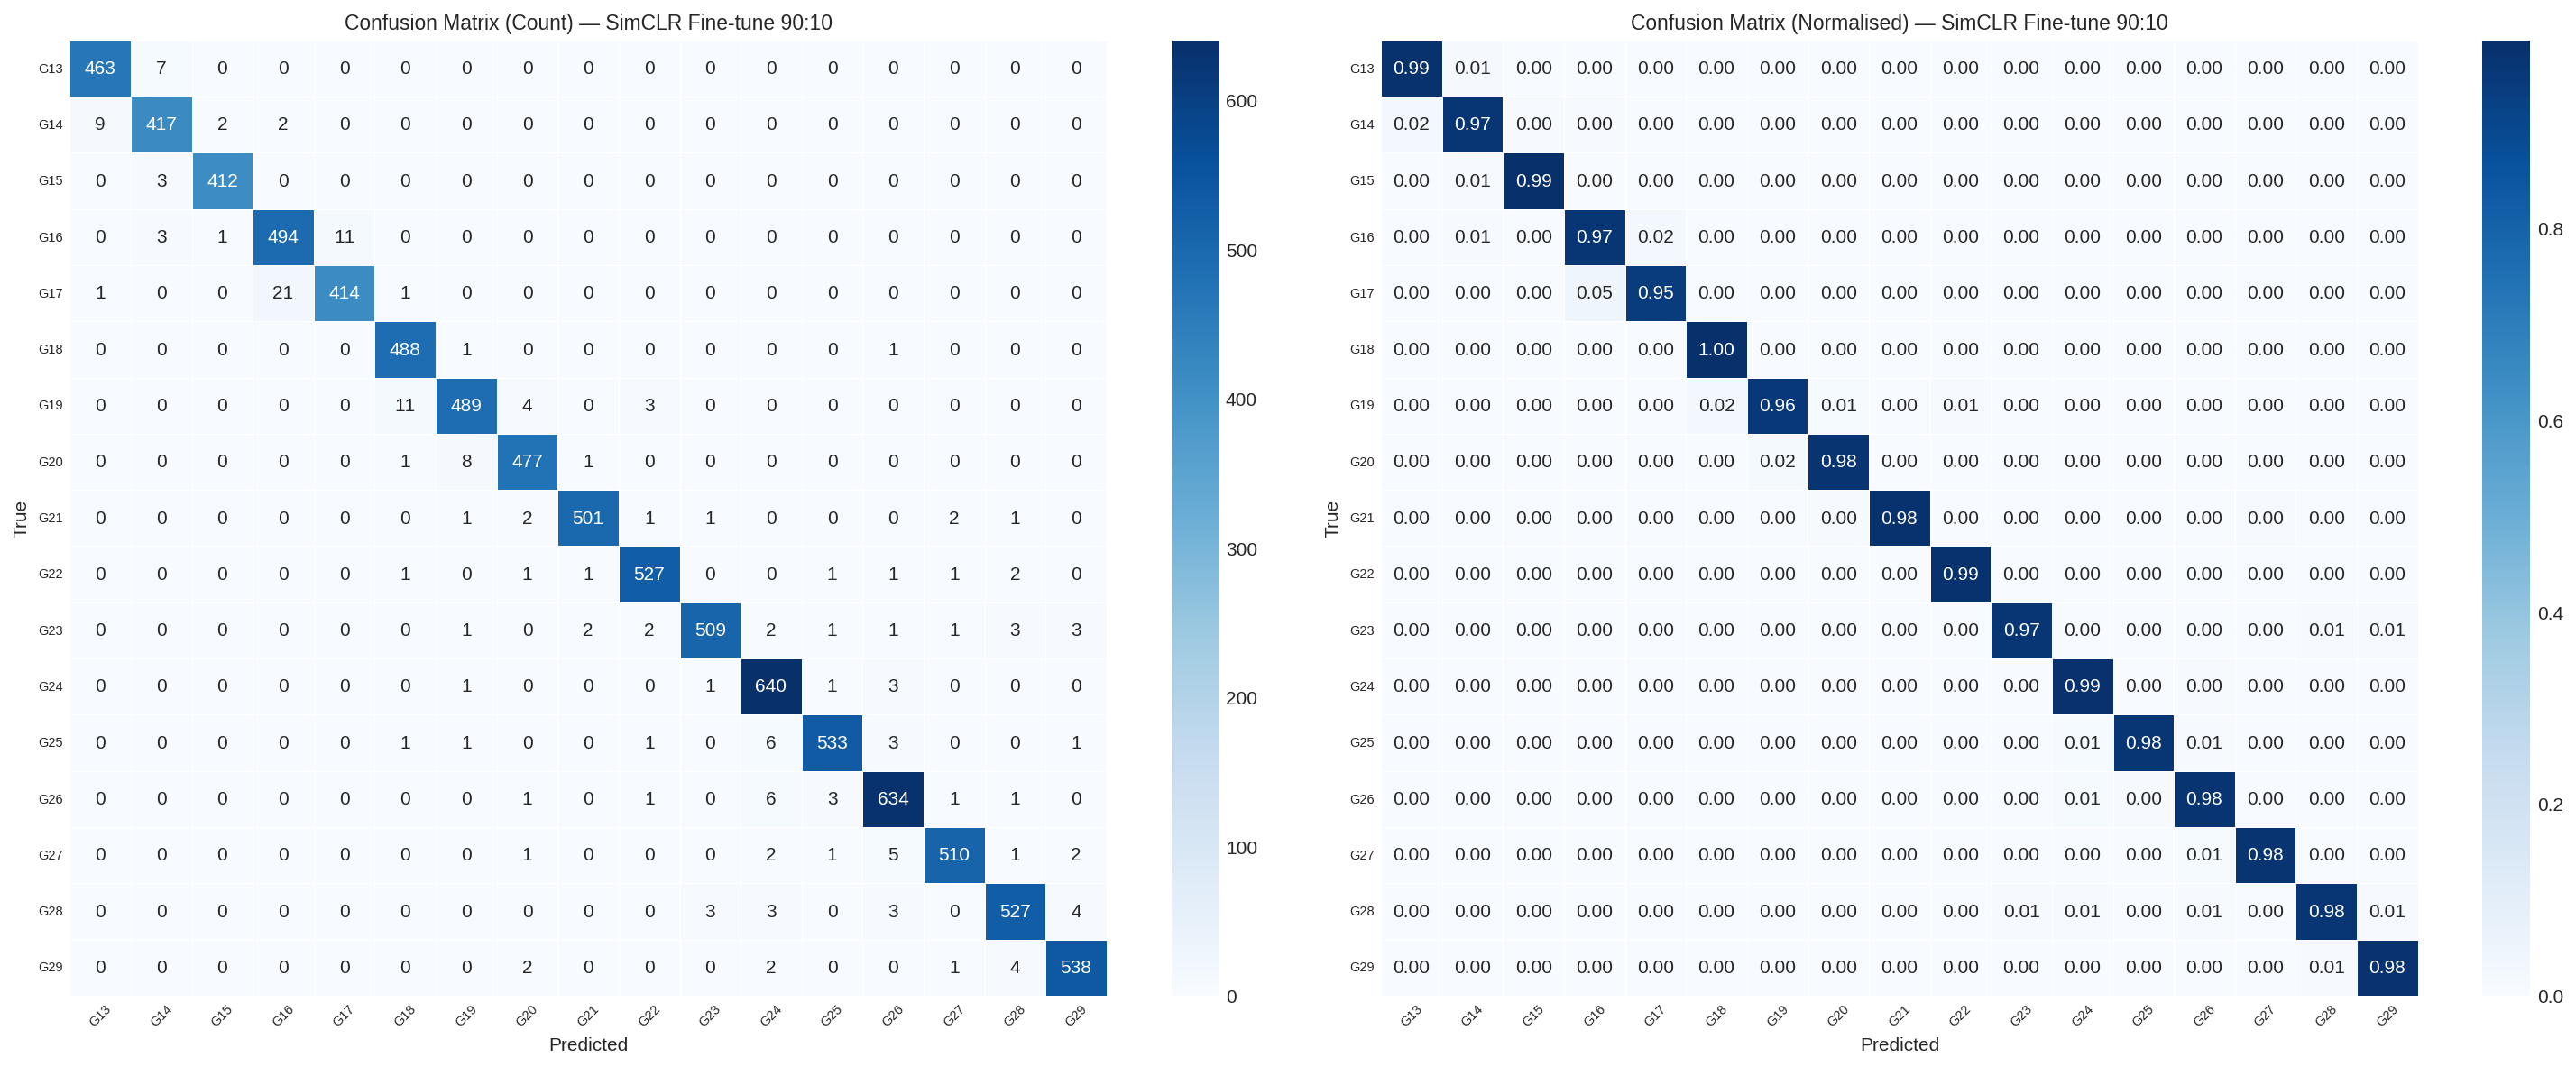


  CM SIMCLR MAIN


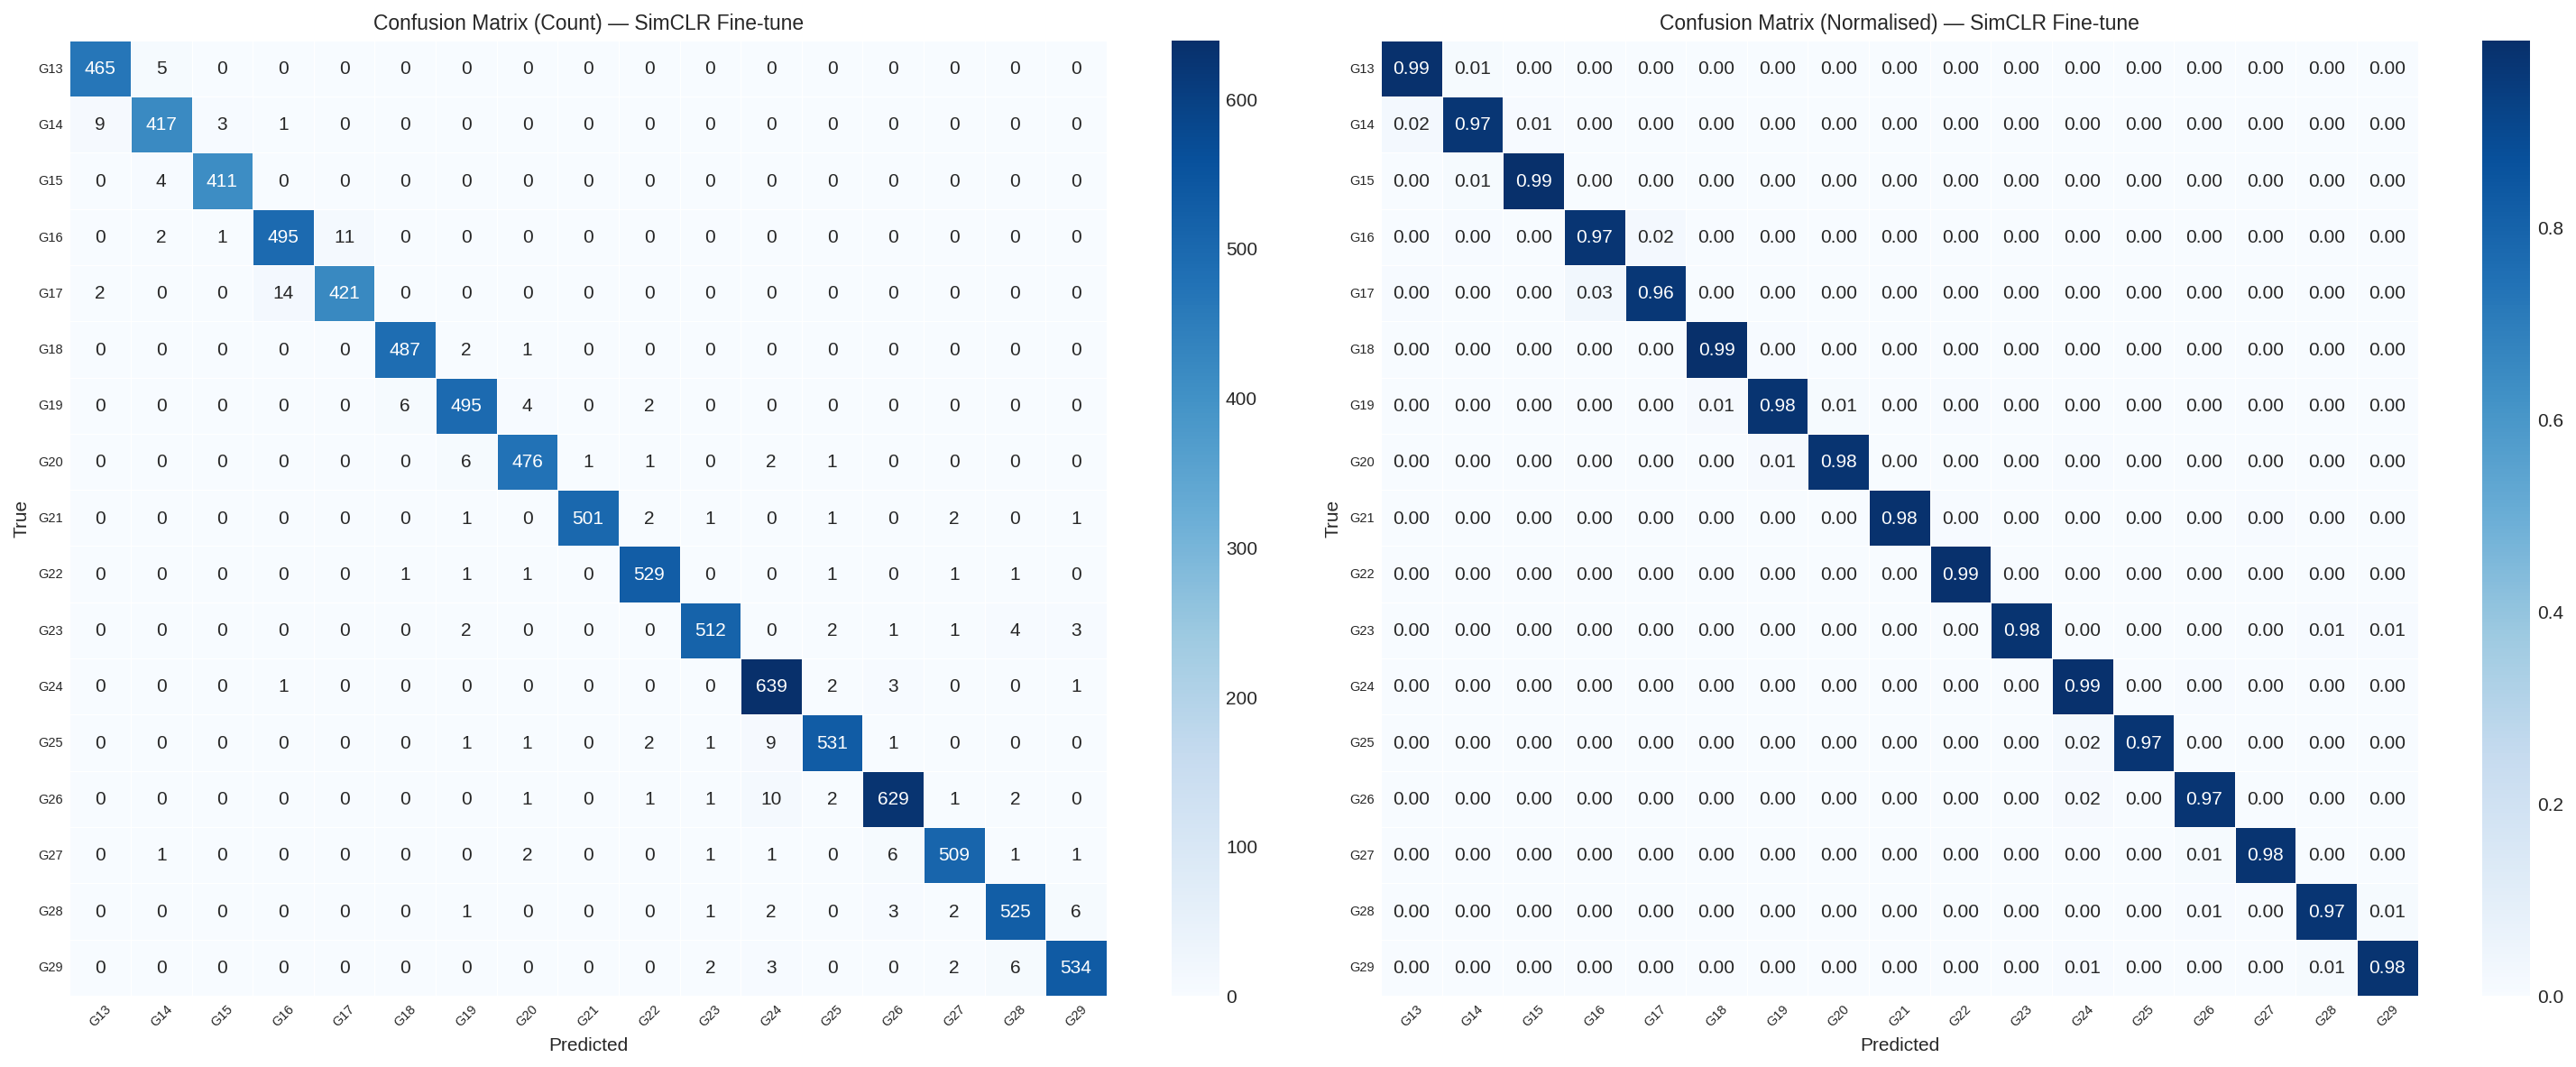


  LABEL EFFICIENCY


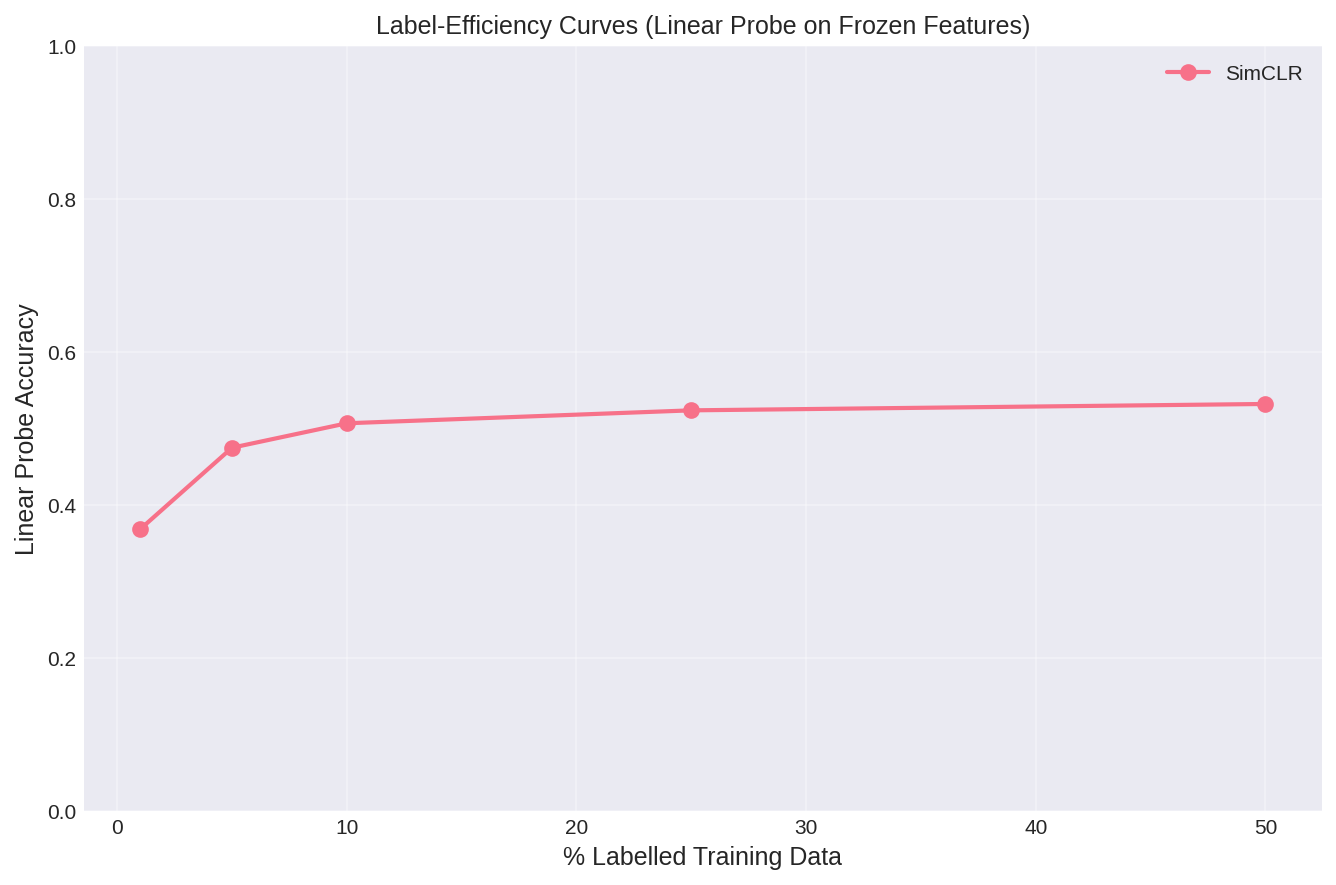


  PCA SIMCLR


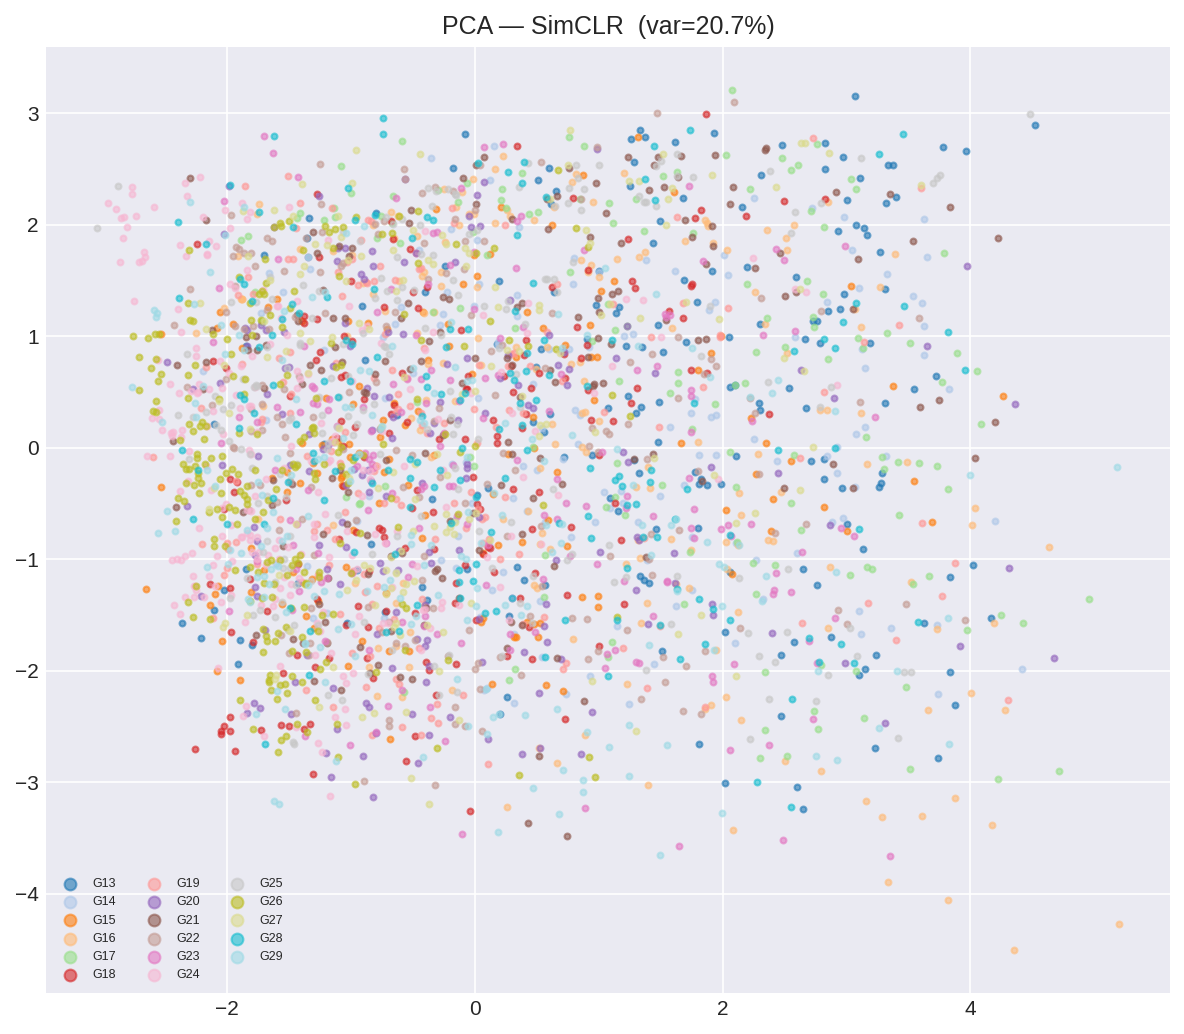


  ROC SIMCLR 90 10


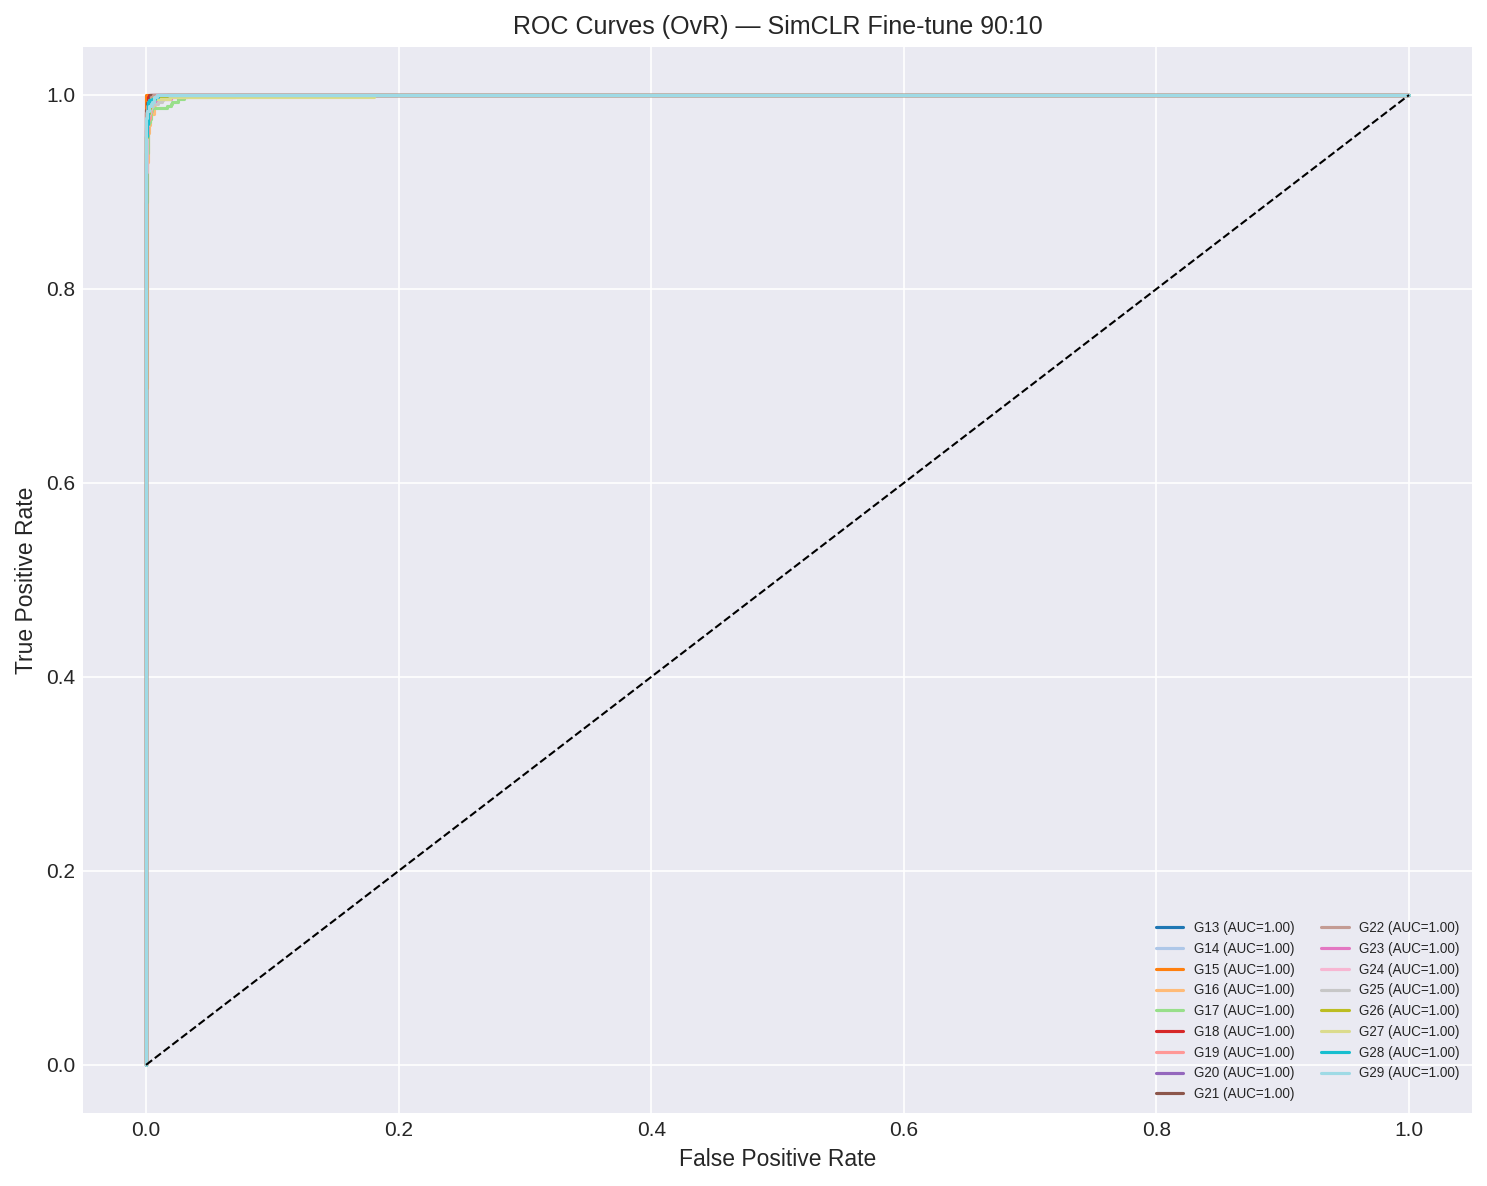


  ROC SIMCLR MAIN


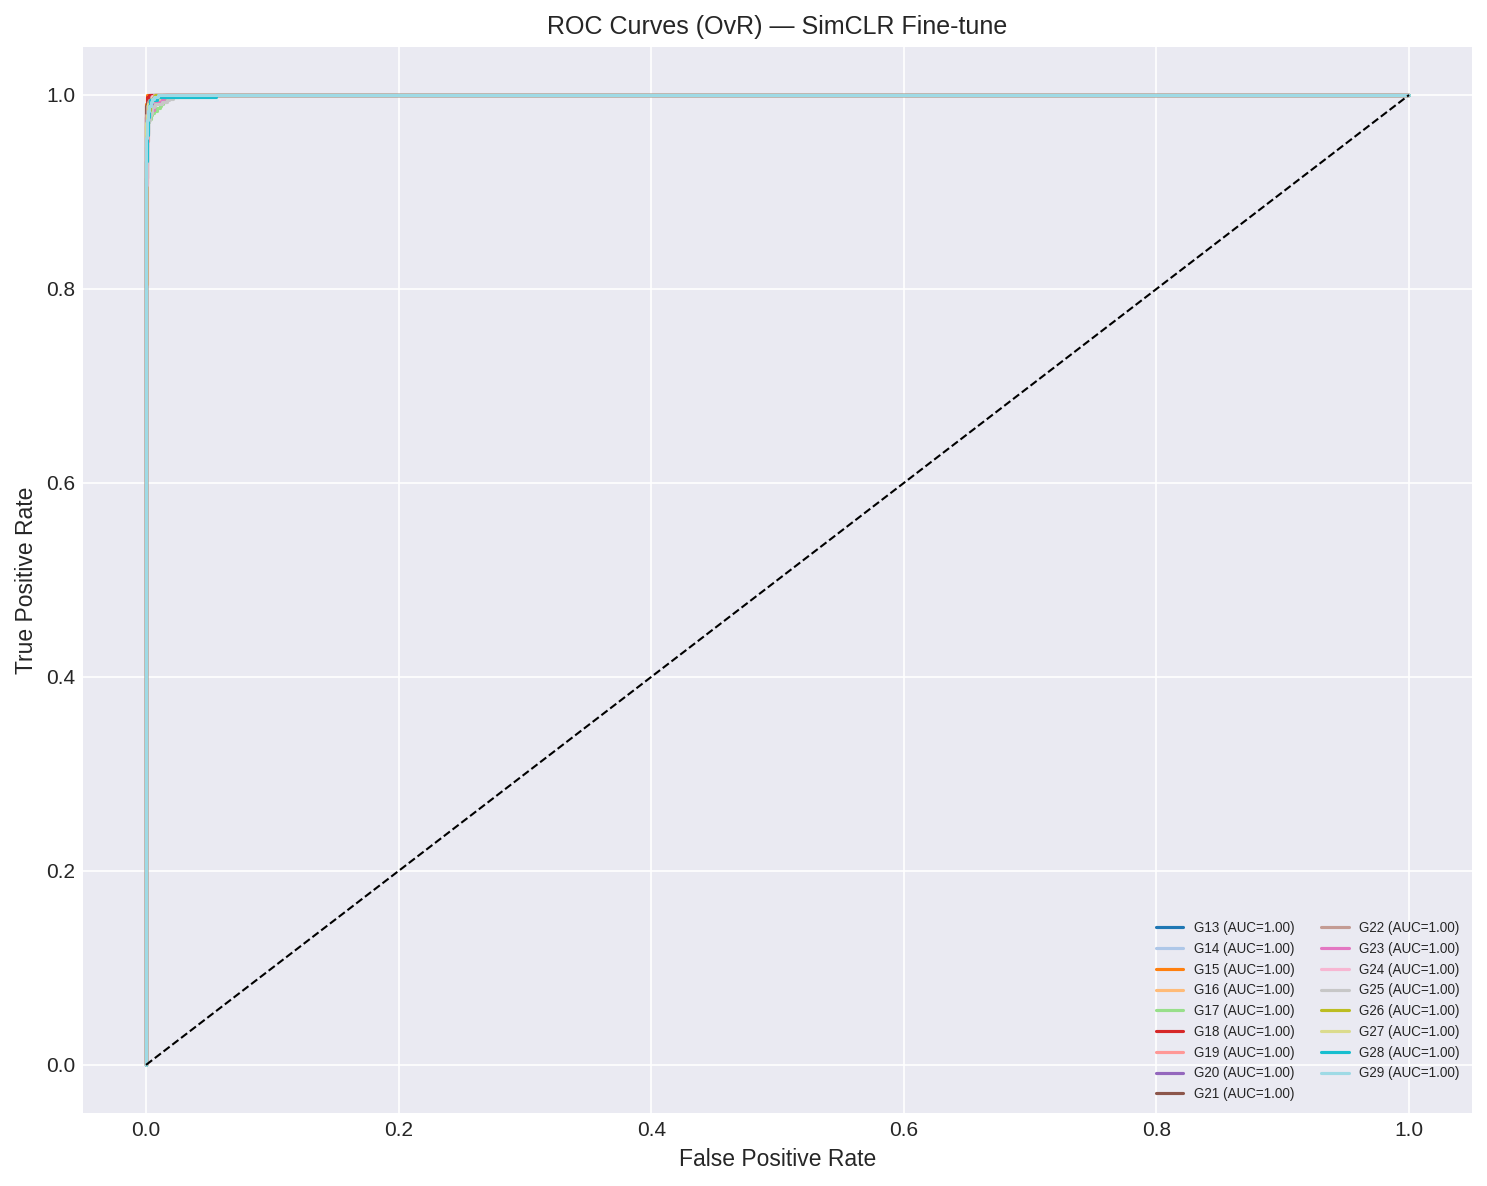


  SSL COMPARISON


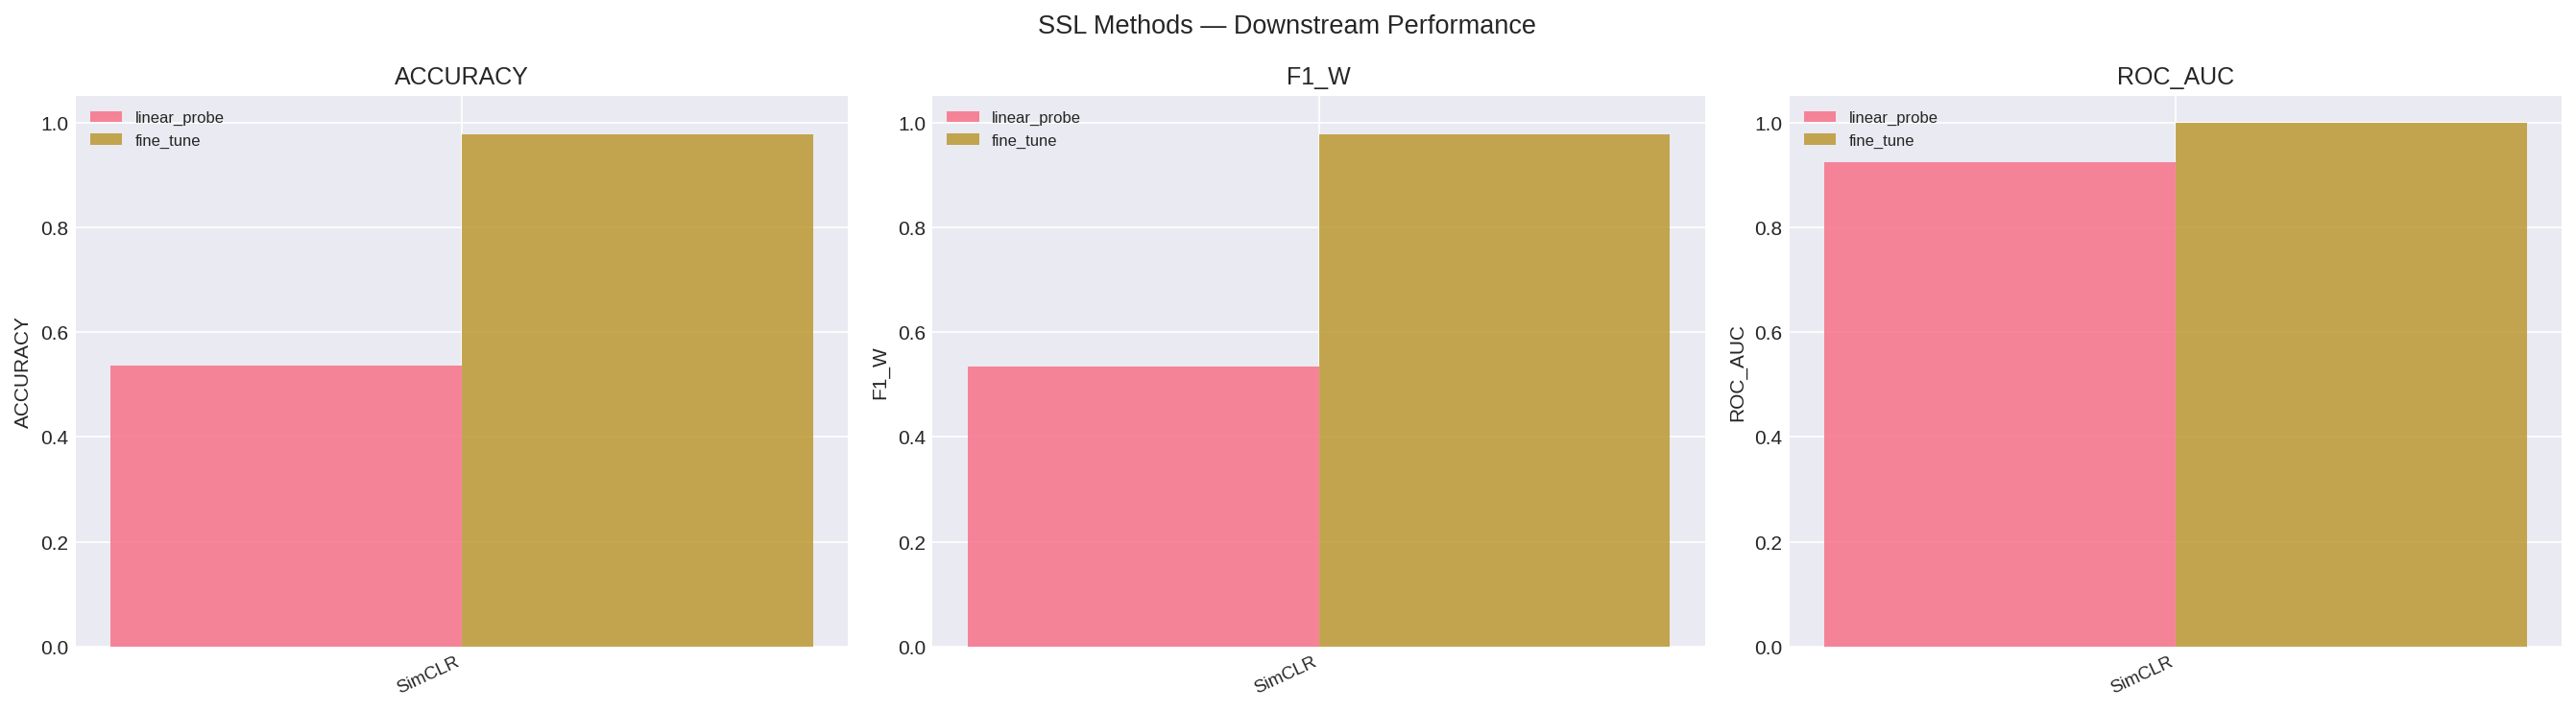


  SSL LOSS CURVES


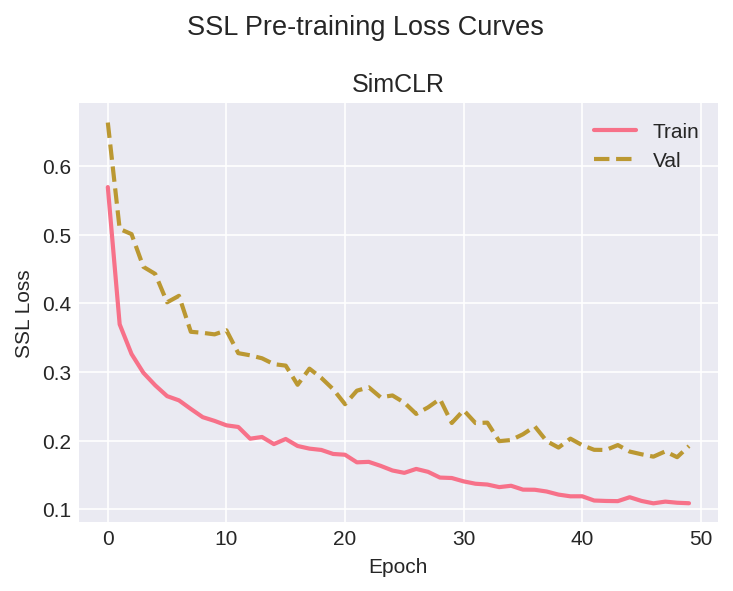


  TSNE SIMCLR


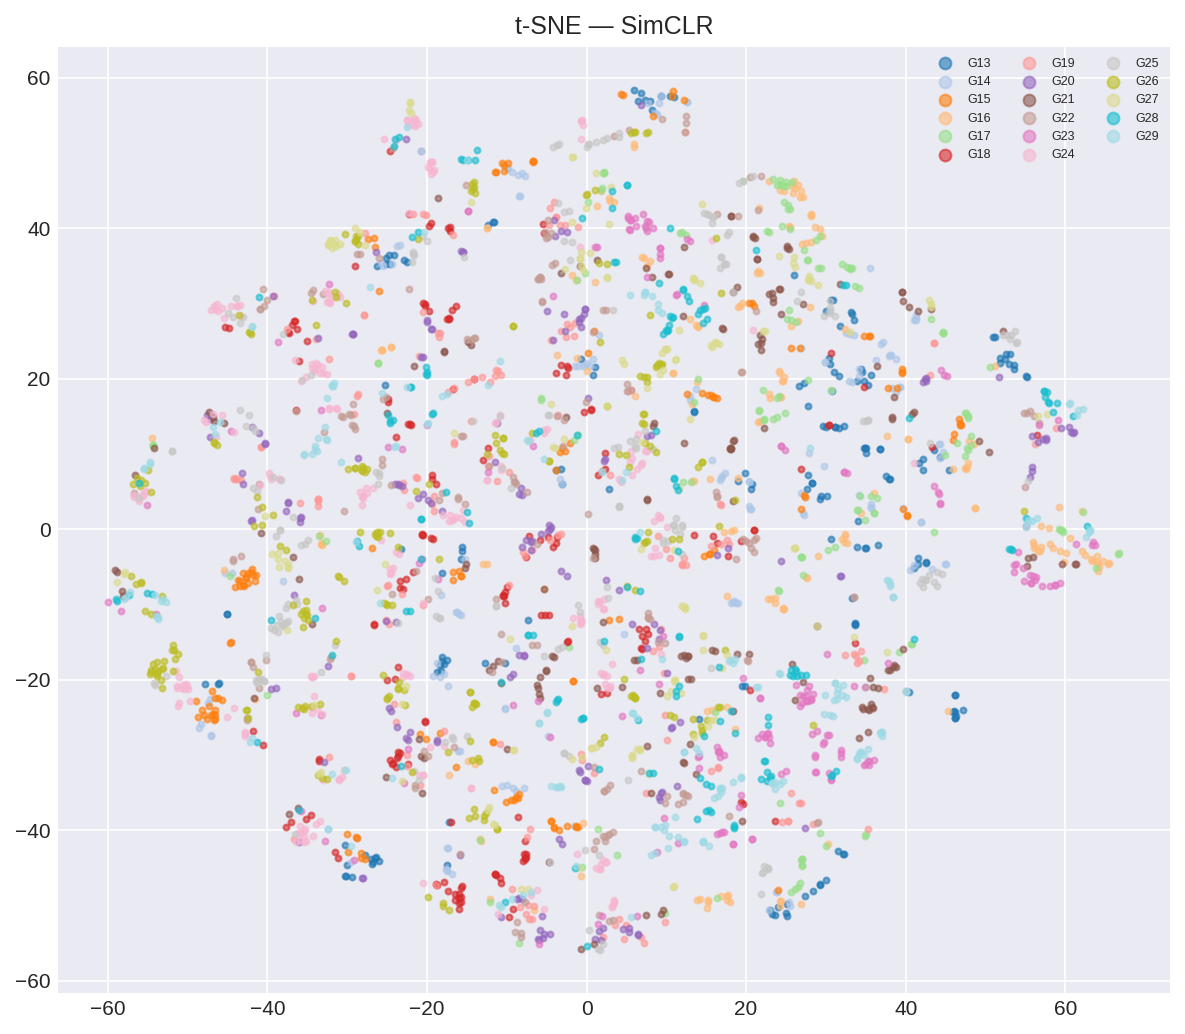


  UMAP SIMCLR


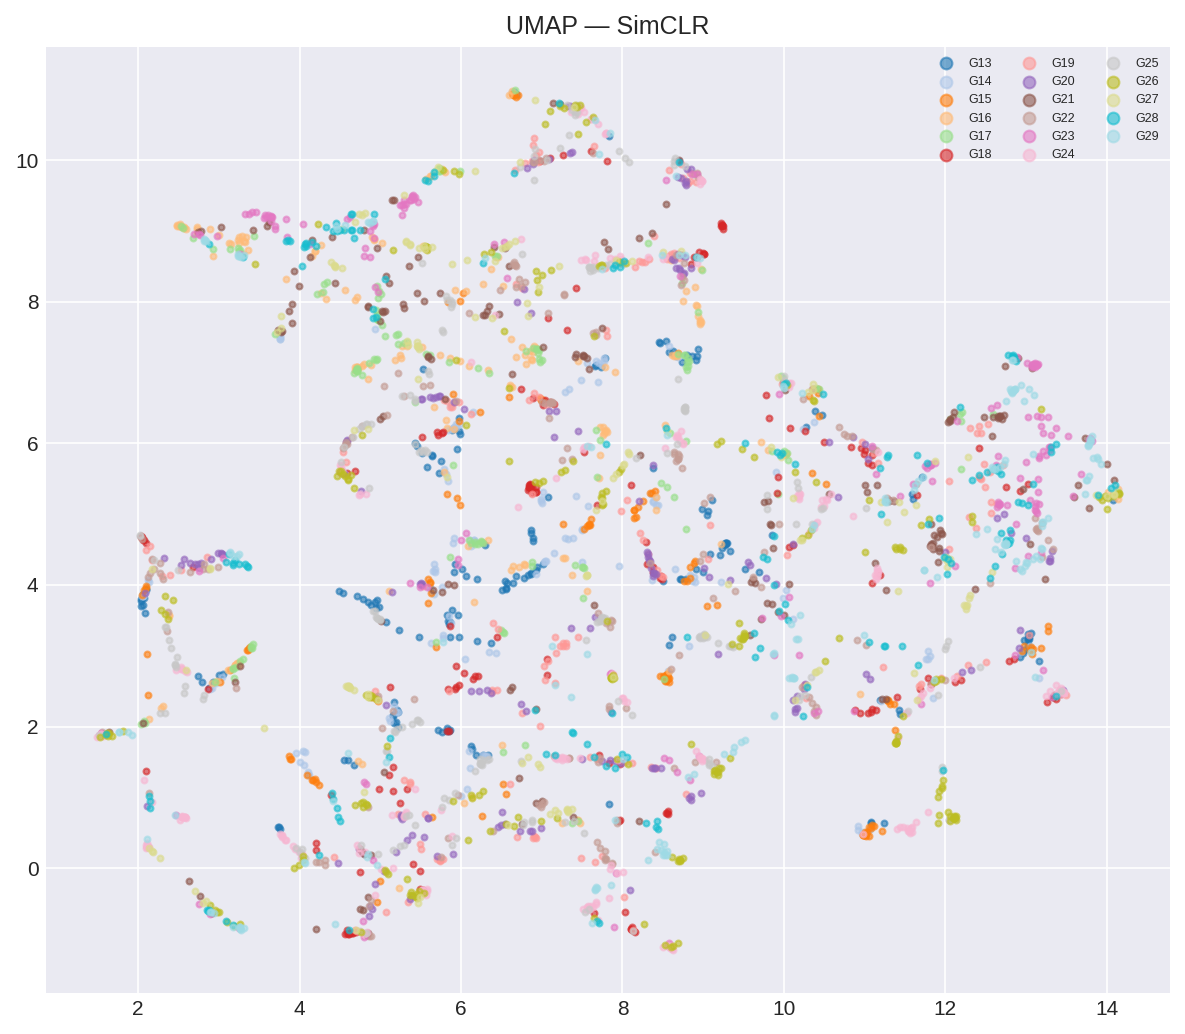

In [33]:
%matplotlib inline
from IPython.display import Image, display
from pathlib import Path

plot_dir = Path('/kaggle/working/plots_ssl')
all_pngs = sorted(plot_dir.glob('*.png'))

if not all_pngs:
    print("No plots found in", plot_dir)
else:
    print(f"Found {len(all_pngs)} plots\n")
    for fpath in all_pngs:
        print(f"\n{'='*60}")
        print(f"  {fpath.stem.upper().replace('_',' ')}")
        print(f"{'='*60}")
        display(Image(filename=str(fpath)))